In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import glob, os, yaml, itertools, subprocess, sys, shutil,sparse

import Bio.SeqUtils
import Bio.Data
from Bio import SeqIO
from Bio.Seq import Seq

plt.rcParams['figure.dpi'] = 150
plt.rcParams['axes.titlepad'] = 10
import scipy.stats as st
import warnings, pickle
warnings.filterwarnings("ignore")
from matplotlib.ticker import MaxNLocator

# load all utils functions
sys.path.append(os.path.join(os.path.dirname(os.getcwd()), "utils"))
from data_utils import *
from inSilicoMut_utils import *

results_path = "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results"
data_dir = "/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs"

who_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/WHO_catalog_clean.csv")
who_variants["gene"] = [mut.split("_")[0] for mut in who_variants["mutation"].values]

h37Rv = SeqIO.read("/n/data1/hms/dbmi/farhat/Sanjana/H37Rv/GCF_000195955.2_ASM19595v2_genomic.gbff", "genbank")
h37Rv_genes = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/H37Rv/mycobrowser_h37rv_genes_v4.csv")

coll_2014 = pd.read_csv("/home/sak0914/who-analysis/data/coll2014_SNP_scheme.tsv", sep="\t")
coll_2014["lineage"] = coll_2014["#lineage"].str.replace("lineage", "")
del coll_2014["#lineage"]

lineages_matrix = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/lineage_matrix_Coll2014.csv", index_col=[0])

h37Rv_seq = SeqIO.read("/n/data1/hms/dbmi/farhat/Sanjana/H37Rv/GCF_000195955.2_ASM19595v2_genomic.gbff", "genbank")

4411532


In [22]:
# model_features = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/PZA_4Loci/ridge/model_features.txt", sep="\t", header=None)
# model_features_peptide = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/PZA_4Loci_peptide/ridge/model_features.txt", sep="\t", header=None)

results = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/PZA_4Loci/ridge/results.csv")
results_peptide = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/PZA_4Loci_peptide/ridge/results.csv")

len(model_features), len(model_features_peptide)

(1230, 1234)

In [18]:
set(model_features[0].values) - set(model_features_peptide[0].values)

set()

In [20]:
results

,Drug,Model,Num_Loci,Binned_MAE,Binned_MSE,MAE,MSE,Within_doubling,Spearman,Pearson,Sensitivity,Specificity,Precision,Accuracy,Balanced_Acc,CV,Lineage
0,PZA,LinReg,4,0.992282,3.199125,1.425551,4.138279,0.662602,0.540951,0.466128,0.59322,0.953125,0.921053,0.780488,0.773173,0,0


In [21]:
results_peptide

,Drug,Model,Num_Loci,Binned_MAE,Binned_MSE,MAE,MSE,Within_doubling,Spearman,Pearson,Sensitivity,Specificity,Precision,Accuracy,Balanced_Acc,CV,Lineage
0,PZA,LinReg,4,0.992022,2.644717,1.408658,3.635441,0.666667,0.586979,0.492415,0.567797,0.984375,0.971014,0.784553,0.776086,0,0


# Introduce Compatible Mutations from the WHO V1 Catalog into H37Rv and Predict with Model

# rpoB, Rifampicin

In [68]:
# # takes a while to run
# rpoBC_ALL = get_VCF_file_information("RIF", 
#                                      "Rifampicin/rpoBC_seqdf.csv", 
#                                      ["rpoB", "rpoC"], 
#                                      "+", 
#                                      759309,
#                                      767683
#                                     )

rpoBC_WHO = pd.read_csv(f"{data_dir}/RIF/inSilico_analysis/rpoBC_WHO_nucleotide_variants.csv")
rpoBC_WHO.mutation.nunique()

1045

In [69]:
# # then write them to new VCF files
# # this also creates a file of the mutation names
# create_synthetic_VCF_files(rpoBC_WHO, 
#                            f"{data_dir}/RIF/inSilico_analysis/rpoBC_WHO_mutations.txt", 
#                            f"{data_dir}/RIF/inSilico_analysis/synthetic_VCF"
#                           )

# gyrA and gyrB, Moxifloxacin

In [70]:
# gyrBA_ALL = get_VCF_file_information("MXF", 
#                                      "Moxifloxacin/gyrBA_seqdf.csv", 
#                                      ["gyrA", "gyrB"], 
#                                      "+", 
#                                      4997, 
#                                      9913
#                                     )

gyrBA_WHO = pd.read_csv(f"{data_dir}/MXF/inSilico_analysis/gyrBA_WHO_nucleotide_variants.csv")
gyrBA_WHO.mutation.nunique()

541

In [8]:
# # then write them to new VCF files
# # this also creates a file of the mutation names
# create_synthetic_VCF_files(gyrBA_WHO, 
#                            f"{data_path}/MXF/inSilico_analysis/gyrBA_WHO_mutations.txt", 
#                            f"{data_path}/MXF/inSilico_analysis/synthetic_VCF"
#                           )

# pncA, Pyrazinamide

In [2]:
who_variants.query("drug=='PZA' & confidence=='1) Assoc w R'").gene.unique()

array(['pncA'], dtype=object)

In [67]:
# pncA_ALL = get_VCF_file_information("PZA", 
#                                      "Pyrazinamide/pncA_seqdf.csv", 
#                                      ["pncA"], 
#                                      "-", 
#                                      2286526,  
#                                      2291268
#                                     )

pncA_WHO = pd.read_csv(f"{data_dir}/PZA/inSilico_analysis/pncA_WHO_nucleotide_variants.csv")
pncA_WHO.mutation.nunique()

357

# Compare in silico WHO catalog predictions between the -Peptide and +Peptide Models

In [4]:
PZA_isolate_variants = pd.read_csv(os.path.join(data_dir, "PZA", "isolate_variants.csv.gz"), compression='gzip')

In [2]:
PZA_peptide_insilico_pred = pd.read_csv("Pyrazinamide/insilico_mutagenesis/pncA_WHO_predictions_peptide.csv")
PZA_peptide_insilico_pred["CNN_MIC"] = np.exp2(PZA_peptide_insilico_pred['CNN_log_MIC'])

PZA_insilico_pred = pd.read_csv("Pyrazinamide/insilico_mutagenesis/pncA_WHO_predictions.csv")
PZA_insilico_pred["CNN_MIC"] = np.exp2(PZA_insilico_pred['CNN_log_MIC'])

for i, row in PZA_peptide_insilico_pred.iterrows():

    if "_p" in row["mutation"]:

        num = []
        for char in row["mutation"].split("_")[1]:
            if char.isnumeric():
                num.append(char)
        PZA_peptide_insilico_pred.loc[i, "codon_num"] = int("".join(num))
    else:
        PZA_peptide_insilico_pred.loc[i, "codon_num"] = 0

combined_insilico_df = PZA_peptide_insilico_pred.rename(columns={'CNN_MIC': 'PZA_peptide_pred_MIC', 'CNN_log_MIC': 'PZA_peptide_pred_log_MIC'}).merge(PZA_insilico_pred[['mutation', 'CNN_MIC', 'CNN_log_MIC']].rename(columns={'CNN_MIC': 'PZA_pred_MIC', 'CNN_log_MIC': 'PZA_pred_log_MIC'}), on='mutation')

combined_insilico_df['log_MIC_diff'] = combined_insilico_df['PZA_peptide_pred_log_MIC'] - combined_insilico_df['PZA_pred_log_MIC']

In [3]:
PZA_peptide_insilico_pred.query("mutation.str.contains('fs')")

,CNN_log_MIC,mutation,confidence,genome_index,CNN_MIC,codon_num


# Compare test set predictions between the -Peptide and +Peptide Models

In [20]:
df_phenos = pd.read_csv(os.path.join(data_dir, "PZA", "data_for_model.csv"))
locus_peptide_lengths = pd.read_csv(os.path.join(results_path, "PZA_4Loci", "locus_peptide_lengths.csv"), index_col=[0])

PZA_pred = pd.read_csv(os.path.join(results_path, "PZA_4Loci", "test_predictions.csv"))
PZA_peptide_pred = pd.read_csv(os.path.join(results_path, "PZA_4Loci_peptide", "test_predictions.csv"))

combined_pred_df = PZA_pred[['Isolate', 'y_pred', 'y_test', 'lower', 'upper']].merge(PZA_peptide_pred[['Isolate', 'y_pred']].rename(columns={'y_pred': 'y_peptide_pred'}), on='Isolate')
combined_pred_df['log_MIC_diff'] = combined_pred_df['y_peptide_pred'] - combined_pred_df['y_pred']
combined_pred_df['MIC_diff'] = np.exp2(combined_pred_df['y_peptide_pred']) - np.exp2(combined_pred_df['y_pred'])

# samples in the test set with early stop codons (including ambiguous ones that aren't reflected in the lengths because translation of a codon containing N will not be the stop codon)
isolates_with_pncA_disruption = PZA_isolate_variants.query("POS > 2286526 & POS <= 2291268 & GENE.str.contains('pncA') & EFFECT.str.contains('|'.join(['stop_gained', 'ablation', 'gene_fusion']))").Isolate.values
print(f"{len(isolates_with_pncA_disruption)} total isolates with pncA disruptions")

pncA_disrupted_test_data = combined_pred_df.query("Isolate in @isolates_with_pncA_disruption").melt(id_vars='Isolate', value_vars=['y_peptide_pred', 'y_pred']).rename(columns={'Isolate': 'mutation'})
print(f"{pncA_disrupted_test_data.mutation.nunique()} test isolates with pncA disruptions")

pncA_disrupted_test_data['variable'] = pncA_disrupted_test_data['variable'].replace('y_pred', '- Peptide Lengths').replace('y_peptide_pred', '+ Peptide Lengths')
pncA_disrupted_test_data['value'] = np.exp2(pncA_disrupted_test_data['value']) # these are currently log2-transformed
pncA_disrupted_test_data['mutation'] = [val + ' (>500)' for val in pncA_disrupted_test_data['mutation'].values]

# combine them to plot on the same graph
insilico_disrupted_df_plot = combined_insilico_df.query("mutation.str.contains('\\*')").melt(id_vars=['mutation', 'codon_num'], value_vars=['PZA_peptide_pred_MIC', 'PZA_pred_MIC']).sort_values('codon_num', ascending=True).reset_index(drop=True)

insilico_disrupted_df_plot['variable'] = insilico_disrupted_df_plot['variable'].replace('PZA_pred_MIC', '- Peptide Lengths').replace('PZA_peptide_pred_MIC', '+ Peptide Lengths')

# insilico_disrupted_df_plot = pd.concat([insilico_disrupted_df_plot, pncA_disrupted_test_data])

32 total isolates with pncA disruptions
4 test isolates with pncA disruptions


In [6]:
def plot_change_MIC_predictions(df, figsize=(6.4, 4.8)):

    fig, ax = plt.subplots(figsize=figsize)
    
    sns.stripplot(data=df,
                  x='value',
                  y='mutation',
                  hue='variable',
                  hue_order=['- Peptide Lengths', '+ Peptide Lengths'],
                  # palette='Set2',
                  log_scale=10,
                  size=6,
                  edgecolor='black',
                  linewidth=1,
                  jitter=False,
                  ax=ax,
                  zorder=2
                 )
    
    plt.hlines(y=ax.get_yticks(), xmin=df.query("variable=='- Peptide Lengths'")['value'].values, 
               xmax=df.query("variable=='+ Peptide Lengths'")['value'].values, 
               color='darkgray',
               linewidth=1,
               zorder=1
              )
    
    # plt.axvline(x=100, color='black', linewidth=0.75, linestyle='--', zorder=0, label='CC = 100')
    # plt.axvline(x=500, color='black', linewidth=0.75, linestyle='--', zorder=0, label='MIC = 500')
    
    plt.legend(title='', loc='best', fontsize='9')
    plt.xlabel('Predicted MIC (µg/mL)')
    plt.ylabel("")
    plt.xlim(left=10)
    sns.despine()
    plt.show()

In [7]:
# test set isolates with a nonsense mutation, gene fusion, or feature ablation
PZA_isolate_variants.query("Isolate in @isolates_with_pncA_nonsense & Isolate in @combined_pred_df.Isolate & GENE.str.contains('pncA')")

,POS,REF,ALT,FILTER,AF,GENE,EFFECT,NUC,PROT,Isolate
765672,2288400,CACAGCCGAGTCCATCGCGACCTCGAGTTCGAGATCGCGCAGCACC...,C,PASS,.,Rv2042c&pncA,gene_fusion,n.2289220_2288401del,.,Peru4070
1371584,2287251,CCCGACCGGCCCTGCTTGGTAAGCGCCTGGGCGGCATCCAGGAATT...,C,PASS,.,Rv2041c&Rv2042c&Rv2044c&pncA,feature_ablation,n.2289592_2287252del,.,Peru5003
1428501,2288933,G,C,PASS,1.0,pncA,stop_gained,c.309C>G,p.Tyr103*,Peru5077
1521234,2288878,G,A,PASS,1.0,pncA,stop_gained,c.364C>T,p.Gln122*,Peru5149


In [21]:
pncA_disrupted_test_data.query("mutation in ['Peru4070 (>500)', 'Peru5003 (>500)']").sort_values(["mutation", "variable"], ascending=[True, False])

,mutation,variable,value
4,Peru4070 (>500),- Peptide Lengths,5.273560e+30
0,Peru4070 (>500),+ Peptide Lengths,3.844809e+22
5,Peru5003 (>500),- Peptide Lengths,1.125189e+30
1,Peru5003 (>500),+ Peptide Lengths,3.458767e+25


In [22]:
pncA_disrupted_test_data.query("mutation in ['Peru5149 (>500)', 'Peru5077 (>500)']")

,mutation,variable,value
2,Peru5077 (>500),+ Peptide Lengths,422.209725
3,Peru5149 (>500),+ Peptide Lengths,1233.896782
6,Peru5077 (>500),- Peptide Lengths,54.416264
7,Peru5149 (>500),- Peptide Lengths,547.126643


In [23]:
df_phenos.query("ROLLINGDB_ID in ['Peru4070', 'Peru5003', 'Peru5077', 'Peru5149']")

,ROLLINGDB_ID,BIOSAMPLE_ACCESSION,ID,ISOLATION_LOCATION,DB_OF_ORIGIN,STUDY_NAME,STUDY_PMID,TESTING_LOCATION,MEDIA,PZA,PZA_lower_bound,PZA_upper_bound,PZA_midpoint,Path,Coll2014,Binary,Lineage,category
442,Peru4070,SAMN05919591,Peru4070,Peru,farhat_internal,NaN,NaN,NJH,m7h10,>500,500.0,inf,500.0,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF/...,4.3.2,1,4,original_test_set
868,Peru5003,SAMN05916324,Peru5003,Peru,farhat_internal,NaN,NaN,NJH,m7h10,>500,500.0,inf,500.0,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF/...,4,1,4,original_test_set
906,Peru5077,SAMN05916389,Peru5077,Peru,farhat_internal,NaN,NaN,NJH,m7h10,>500,500.0,inf,500.0,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF/...,4.1.2.1,1,4,original_test_set
972,Peru5149,SAMN05916453,Peru5149,Peru,farhat_internal,NaN,NaN,NJH,m7h10,>500,500.0,inf,500.0,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF/...,4.1.2.1,1,4,original_test_set


In [25]:
insilico_disrupted_df_plot.query("mutation in ['pncA_p.Ser164*', 'pncA_p.Glu181*']")

,mutation,codon_num,variable,value
28,pncA_p.Ser164*,164.0,- Peptide Lengths,345.248898
29,pncA_p.Ser164*,164.0,+ Peptide Lengths,91.680665
30,pncA_p.Glu181*,181.0,+ Peptide Lengths,37.459164
31,pncA_p.Glu181*,181.0,- Peptide Lengths,32.272410


In [26]:
# Wilcoxon signed-rank test, which is a nonparametric paired t-test
st.wilcoxon(combined_insilico_df.query("mutation.str.contains('\\*')")['PZA_peptide_pred_log_MIC'], 
            combined_insilico_df.query("mutation.str.contains('\\*')")['PZA_pred_log_MIC'], 
            alternative='greater'
           )

WilcoxonResult(statistic=134.0, pvalue=4.57763671875e-05)

In [30]:
# 4 isolates in the test set with nonsense mutations or large disruptions to pncA
len(combined_pred_df.query("Isolate in @isolates_with_pncA_disruption"))

4

In [31]:
# 3 isolates where they are both predicted R correctly
cc = np.log2(100)
combined_pred_df.query("Isolate in @isolates_with_pncA_disruption & y_pred >= @cc & y_peptide_pred >= @cc")

,Isolate,y_pred,y_test,lower,upper,y_peptide_pred,log_MIC_diff,MIC_diff
93,Peru4070,102.056620,8.965784,500.0,inf,75.025330,-27.031290,-5.273560e+30
178,Peru5003,99.828010,8.965784,500.0,inf,84.838460,-14.989550,-1.125154e+30
195,Peru5149,9.095731,8.965784,500.0,inf,10.269006,1.173275,6.867701e+02


In [32]:
# 0 cases where the peptide model predicted S and the original model predicted R -- GOOD
combined_pred_df.query("Isolate in @isolates_with_pncA_disruption & y_pred >= @cc & y_peptide_pred < @cc")

,Isolate,y_pred,y_test,lower,upper,y_peptide_pred,log_MIC_diff,MIC_diff


In [33]:
# 1 case where the original model missed an R isolate and the peptide model got it
combined_pred_df.query("Isolate in @isolates_with_pncA_disruption & y_pred < @cc & y_peptide_pred >= @cc")

,Isolate,y_pred,y_test,lower,upper,y_peptide_pred,log_MIC_diff,MIC_diff
184,Peru5077,5.765966,8.965784,500.0,inf,8.721816,2.95585,367.793461


In [34]:
# 0 cases where they are both predicted susceptible -- GOOD
combined_pred_df.query("Isolate in @isolates_with_pncA_disruption & y_pred < @cc & y_peptide_pred < @cc")

,Isolate,y_pred,y_test,lower,upper,y_peptide_pred,log_MIC_diff,MIC_diff


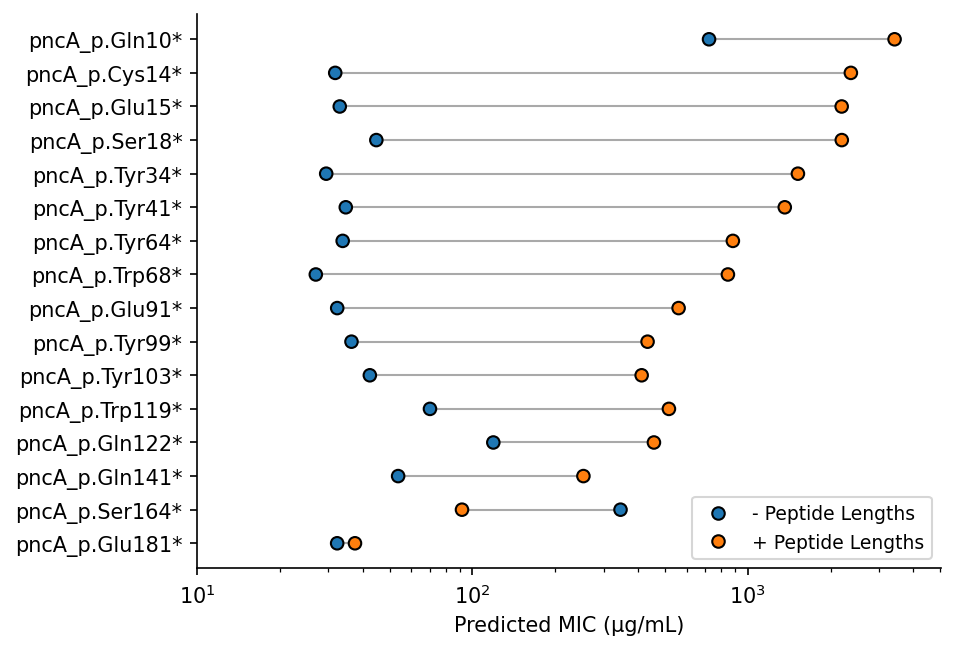

In [37]:
plot_change_MIC_predictions(insilico_disrupted_df_plot)

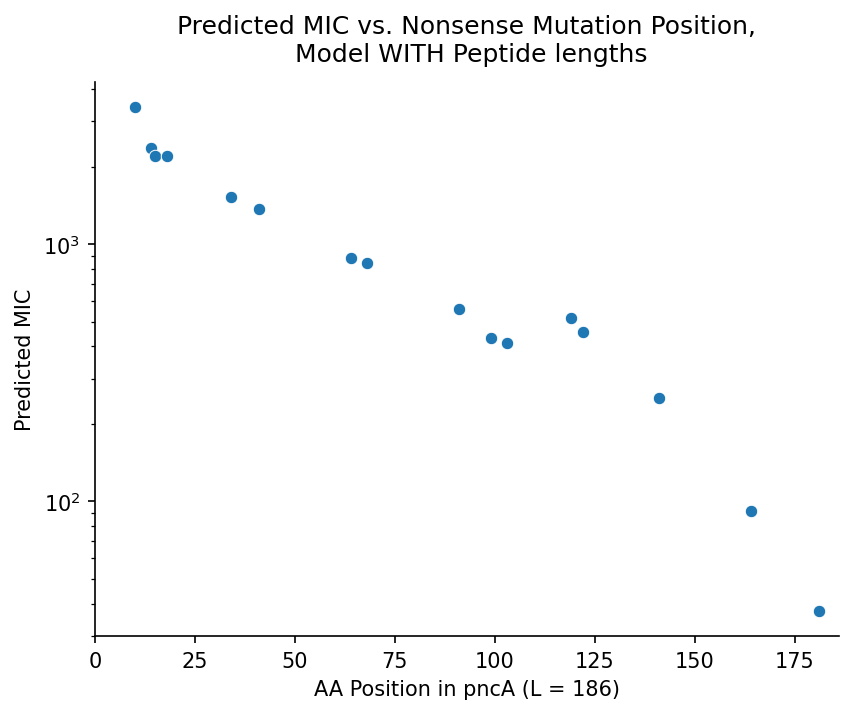

In [36]:
sns.scatterplot(data=insilico_disrupted_df_plot.query("variable == '+ Peptide Lengths'"),
                x="codon_num",
                y="value",
               )

plt.xlabel("AA Position in pncA (L = 186)")
plt.ylabel("Predicted MIC")
plt.title("Predicted MIC vs. Nonsense Mutation Position,\n Model WITH Peptide lengths")

plt.xlim(left=0, right=186)
plt.yscale('log')
sns.despine()
plt.show()

In [39]:
st.spearmanr(insilico_disrupted_df_plot.query("variable == '+ Peptide Lengths'")['codon_num'],
             insilico_disrupted_df_plot.query("variable == '+ Peptide Lengths'")['value']
            )

SignificanceResult(statistic=-0.9735294117647059, pvalue=2.276897655666222e-10)

In [41]:
# sns.scatterplot(data=insilico_disrupted_df_plot.query("variable == '- Peptide Lengths'"),
#                 x="codon_num",
#                 y="value",
#                )

# plt.xlabel("AA Position in pncA (L = 186)")
# plt.ylabel("Predicted MIC")
# plt.title("Predicted MIC vs. Nonsense Mutation Position,\n Model WITHOUT Peptide lengths")

# plt.xlim(left=0, right=186)
# plt.yscale('log')
# sns.despine()
# plt.show()

In [42]:
insilico_disrupted_df_plot.query("variable == '- Peptide Lengths' & mutation in ['pncA_p.Tyr103*', 'pncA_p.Gln122*']")

,mutation,codon_num,variable,value
21,pncA_p.Tyr103*,103.0,- Peptide Lengths,42.418362
25,pncA_p.Gln122*,122.0,- Peptide Lengths,119.136403


In [43]:
st.spearmanr(insilico_disrupted_df_plot.query("variable == '- Peptide Lengths'")['codon_num'],
             insilico_disrupted_df_plot.query("variable == '- Peptide Lengths'")['value']
            )

SignificanceResult(statistic=0.2441176470588235, pvalue=0.3622134961419501)

In [167]:
combined_pred_df["pred_MIC"] = np.exp2(combined_pred_df["y_pred"])
combined_pred_df["peptide_pred_MIC"] = np.exp2(combined_pred_df["y_peptide_pred"])

In [173]:
combined_pred_df.query("y_pred > y_peptide_pred")

,Isolate,y_pred,y_test,lower,upper,y_peptide_pred,log_MIC_diff,MIC_diff,pred_MIC,peptide_pred_MIC
1,1719,4.706104,2.321928,0.0,10.0,4.672506,-0.033598,-6.008504e-01,2.610228e+01,2.550143e+01
2,1738,3.613474,3.906891,10.0,20.0,3.105583,-0.507891,-3.632074e+00,1.223951e+01,8.607434e+00
4,1821,4.706104,2.321928,0.0,10.0,4.672506,-0.033598,-6.008504e-01,2.610228e+01,2.550143e+01
5,1832,4.706104,3.906891,10.0,20.0,4.672506,-0.033598,-6.008504e-01,2.610228e+01,2.550143e+01
6,NLA000001061,4.590306,2.321928,0.0,10.0,4.515475,-0.074831,-1.217626e+00,2.408906e+01,2.287144e+01
...,...,...,...,...,...,...,...,...,...,...
197,Peru5409,8.790043,8.965784,500.0,inf,6.409579,-2.380464,-3.576452e+02,4.426563e+02,8.501110e+01
198,Peru5415,6.958265,7.076816,120.0,150.0,6.360699,-0.597567,-4.217118e+01,1.243502e+02,8.217905e+01
199,Peru5420,31.993753,6.781360,100.0,120.0,31.039175,-0.954578,-2.069814e+09,4.276410e+09,2.206595e+09
200,Peru5427,4.706104,3.643856,0.0,25.0,4.672507,-0.033597,-6.008327e-01,2.610228e+01,2.550145e+01


In [169]:
combined_pred_df.query("pred_MIC >= lower & pred_MIC <= upper").shape, combined_pred_df.query("peptide_pred_MIC >= lower & peptide_pred_MIC <= upper").shape

((65, 10), (54, 10))

In [ ]:
combined_pred_df.query("pred_MIC >= lower & pred_MIC <= upper").shape, combined_pred_df.query("peptide_pred_MIC >= lower & peptide_pred_MIC <= upper").shape

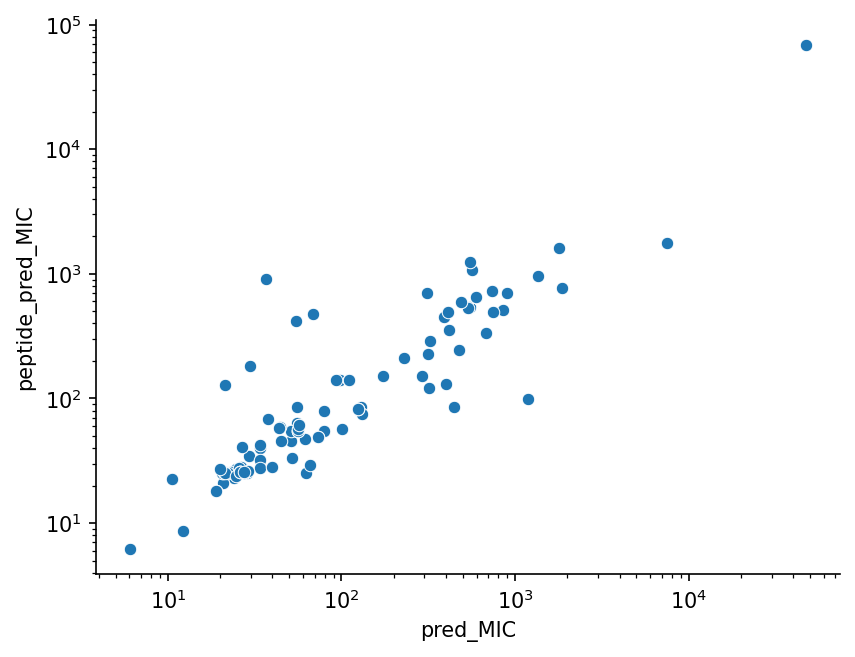

In [172]:
sns.scatterplot(data=combined_pred_df.query("pred_MIC < 100000"),
                x="pred_MIC",
                y="peptide_pred_MIC"
               )

plt.xscale("log")
plt.yscale("log")
sns.despine()
plt.show()

In [11]:
# # then write them to new VCF files
# # this also creates a file of the mutation names
# create_synthetic_VCF_files(pncA_WHO, 
#                            f"{data_path}/PZA/inSilico_analysis/pncA_WHO_mutations.txt", 
#                            f"{data_path}/PZA/inSilico_analysis/synthetic_VCF"
#                           )

```bash
python3 -u data_processing/make_MSA.py /n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/PZA/combined_paths_for_aln.txt /n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUST/samples_full_paths.txt /n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/PZA/inSilico_analysis/pncA_WHO_mutations.txt 2286526 2291268 "NEG" /n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/PZA/inSilico_analysis/pncA.fasta TRUE
```

# Write Variants to Synthetic VCF Files and Save a txt file of them

## Both of these components are needed to run <code>06_make_MSA.py</code>

In [5]:
# # then write them to new VCF files
# # this also creates a file of the mutation names

# shutil.rmtree("/n/scratch3/users/s/sak0914/synthetic_VCF")

In [9]:
def remove_mutations_to_preserve_aln(model_aln_df, full_aln_df, START, vcf_df):
    
    print(f"Original aln insertions: {model_aln_df['len_insertion'].sum()}")
    print(f"In silico aln insertions: {full_aln_df['len_insertion'].sum()}")
    
    model_aln_df["name"] = "old"
    full_aln_df["name"] = "new"

    insertions_combined = model_aln_df.merge(full_aln_df, on="aln_idx", how="outer")

    # idx + START + 1 = record.POS. Add 1 to START because it is 0-indexed
    insertions_combined["POS"] = insertions_combined["aln_idx"] + START + 1
    
    # x = old, y = new
    search_df = insertions_combined.loc[insertions_combined['len_insertion_x'] != insertions_combined['len_insertion_y']]#insertions_combined.loc[pd.isnull(insertions_combined["name_x"])]

    vcf_df["REF_len"] = [len(val) for val in vcf_df["REF"]]
    vcf_df["ALT_len"] = [len(val) for val in vcf_df["ALT"]]

    drop_mutations = vcf_df.query("POS in @search_df.POS & ALT_len > REF_len")[["confidence", "mutation", "POS", "REF", "ALT"]].mutation.values
    print(drop_mutations)
    print(f"Dropped {len(drop_mutations)} mutations to preserve the alignment")

    vcf_df_cleaned = vcf_df.query("mutation not in @drop_mutations")
    print(len(vcf_df.mutation.unique()), len(vcf_df_cleaned.mutation.unique()))
    
    return vcf_df_cleaned

Finished reading 10578 sequences!
     idx  len_insertion
0     27              1
1     37             21
2    226              6
3    753             12
4   1486              3
5   1488              3
6   1491              3
7   1495              3
8   1704              3
9   2202              3
10  2741              6
11  2820              3
12  3182              6
13  3717              1
14  4750              3
15  5636              3
16  6881              3
17  6884             15
18  7002             12
19  7063              6
Aligned region size: 7826

After updating the script:

0     27              1
1     37              1
2    226              6
3    753             12
4   1486              3
5   1488              3
6   1491              3
7   1495              3
8   1704              3
9   2202              3
10  2741              6
11  2820              3
12  3182              6
13  3717              1
14  4750              3
15  5636              3
16  6881              3
17  6884             15
18  7002             12
19  7063              6

In [19]:
# original dataframe of insertions when the original training data and MIC_ML validation data were aligned
rpoB_aln_OLD = pd.DataFrame({"idx": [95, 328, 338, 527, 780, 1039, 1054, 1787, 1789, 1792, 1796, 2005, 2503, 3042, 3121, 3483, 4018, 5051, 5937, 7169, 7182, 7185, 7303, 7364, 8132, 8295],
                            "len_insertion": [3, 1, 1, 6, 6, 12, 12, 3, 3, 3, 3, 3, 3, 6, 3, 6, 1, 3, 3, 15, 3, 15, 12, 6, 1, 3]
                           })

rpoB_aln_FULL = pd.DataFrame({"idx": [95, 233, 328, 332, 338, 346, 376, 417, 438, 527, 541, 780, 790, 1039, 1054, 1787, 1789, 1792, 1796, 1825, 1999, 2005, 2503, 3042, 3058, 3121, 3483, 4013, 4018, 5051, 5937, 7169, 7182, 7185, 7303, 7314, 7364, 8132, 8295],
                              "len_insertion": [3, 2, 1, 1, 1, 2, 1, 2, 1, 6, 6, 6, 6, 12, 12, 3, 3, 3, 3, 3, 9, 3, 3, 6, 6, 3, 6, 1, 1, 3, 3, 15, 3, 15, 12, 6, 6, 1, 3]
                            })

In [20]:
rpoBC_ALL_NEW = remove_mutations_to_preserve_aln(rpoB_aln_OLD, rpoB_aln_FULL, 759309, rpoBC_ALL)

Original aln insertions: 136
In silico aln insertions: 182
['rpoB_p.Thr444dup' 'rpoB_c.-121_-120insT' 'rpoB_c.-151_-150insGT'
 'rpoB_c.-165_-164insG' 'rpoB_p.Pro15_Ser16insSerPro'
 'rpoB_c.-264_-263insTT' 'rpoB_c.-42_-41insT' 'rpoB_c.-59_-58insT'
 'rpoC_p.Gln1084_Arg1085dup' 'rpoB_p.Arg499_Asn501dup'
 'rpoB_p.Met97_Ser98dup' 'rpoB_c.-80_-79insTT' 'rpoB_p.Asp853_Glu854dup']
Dropped 13 mutations to preserve the alignment
1058 1045


# Create file for rpoA (and all other loci without WHO catalog mutations)

Copy the H37Rv sequence for rpoB and rpoC mutations (don't need to do it for the samples, which are just there for the alignment)

In [24]:
rpoBC_ALL_summary = rpoBC_ALL.groupby("mutation")[["POS", "REF", "ALT"]].agg(lambda x: ','.join(x.astype(str)))

rpoBC_ALL_summary["gene"] = [val.split("_")[0] for val in rpoBC_ALL_summary.index.values]
rpoBC_ALL_summary["variant"] = ["_".join(val.split("_")[1:]) for val in rpoBC_ALL_summary.index.values]
rpoBC_ALL_summary["included?"] = 1

rpoBC_ALL_summary = rpoBC_ALL_summary.merge(rpoBC_ALL[["mutation", "confidence"]].drop_duplicates(), left_index=True, right_on="mutation", how="left").set_index("mutation")

In [25]:
rpoBC_ALL_summary.gene.value_counts()

gene
rpoB    755
rpoC    303
Name: count, dtype: int64

In [26]:
rpoBC_ALL_summary.to_csv("Rifampicin/insilico_mutagenesis/rpoBC_WHO_mutation_summary.csv")

In [27]:
# original dataframe of insertions when the original training data and MIC_ML validation data were aligned
mxf_aln_OLD = pd.DataFrame({"idx": [77, 78, 79, 80, 83, 84, 124, 2160],
                             "len_insertion": [1, 2, 2, 1, 1, 1, 1, 3]
                            })

mxf_aln_FULL = pd.DataFrame({"idx": [77, 78, 79, 80, 83, 84, 124, 182, 2160],
                             "len_insertion": [1, 2, 2, 1, 1, 1, 1, 2, 3]
                            })

gyrBA_ALL_NEW = remove_mutations_to_preserve_aln(mxf_aln_OLD, mxf_aln_FULL, 4997, gyrBA_ALL)

Original aln insertions: 12
In silico aln insertions: 14
['gyrB_c.-60_-59insG' 'gyrB_c.-60_-59insGC']
Dropped 2 mutations to preserve the alignment
543 541


In [8]:
pncA_aln_old = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/PZA/fastas/pncA_insertion_sites.csv")
pncA_aln_insilico = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/PZA/inSilico_analysis/pncA_insertion_sites.csv")

pncA_ALL_NEW = remove_mutations_to_preserve_aln(pncA_aln_old, pncA_aln_insilico, 2286526, pncA_ALL)

Original aln insertions: 70
In silico aln insertions: 95
['pncA_p.Ser65_Ser66insAspTyrSer' 'pncA_p.Ala89_Ala92dup'
 'pncA_c.-30_-29insC' 'pncA_c.-33_-32insG' 'pncA_c.-3_-2insC']
Dropped 5 mutations to preserve the alignment
363 358


In [33]:
pncA_aln_old = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/PZA/fastas/pncA_insertion_sites.csv")
pncA_aln_insilico = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/PZA/inSilico_analysis/pncA_insertion_sites.csv")

pncA_ALL_NEW = remove_mutations_to_preserve_aln(pncA_aln_old, pncA_aln_insilico, 2286526, pncA_ALL)

Original aln insertions: 70
In silico aln insertions: 71
['pncA_p.Val155dup']
Dropped 1 mutations to preserve the alignment
363 362


In [41]:
pncA_ALL.query("mutation=='pncA_p.Val155dup'")

,confidence,mutation,gene,POS,variant,REF,ALT,REF_len,ALT_len
98,2) Assoc w R - Interim,pncA_p.Val155dup,pncA,2288776,p.Val155dup,G,GCAC,1,4


In [11]:
def write_ref_seqs_for_constant_loci(drug, variable_locus, constant_locus_lst):

    seq_with_variants = [seq.id for seq in SeqIO.parse(f"/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/{drug}/inSilico_analysis/{variable_locus}.fasta", "fasta")]

    for locus in constant_locus_lst:
    
        # get the reference sequence for the locus
        locus_seq = [(seq.id, seq.seq) for seq in SeqIO.parse(f"/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/{drug}/fastas/{locus}.fasta", "fasta")]
        ref_seq = str(locus_seq[-1][1])
        print(len(ref_seq))
        
        with open(f"/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/{drug}/inSilico_analysis/{locus}.fasta", "w+") as file:
            for seq in seq_with_variants:
                if variable_locus in seq:
                    file.write(">" + seq + "\n")
                    file.write(ref_seq + "\n")

In [79]:
write_ref_seqs_for_constant_loci('PZA', 'pncA', ['clpC1', 'rpsA', 'panD'])

2930
3008
3362


# Align Synthetic VCF Files to the Training/Validation Isolates

## Example:
```bash
python3 -u data_processing/make_MSA.py /n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MXF/combined_paths_for_aln.txt /n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MXF/inSilico_analysis/gyrBA_WHO_mutations.txt 4997 9913 "POS" /n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MXF/inSilico_analysis/gyrBA.fasta
```

# Predict MICs for Synthetic Sequences (single mutations inserted into H37Rv), using script

In [65]:
def get_predictions_dataframes(drug, drug_abbr, locus, locus_df_for_VCF, include_lineage=False, include_peptide_length=False):

    og_model_suffix = ""
    lineage_model_suffix = ""
    
    if include_lineage:
        og_model_suffix += "_lineage"

    if include_peptide_length:
        og_model_suffix += "_peptide"
        lineage_model_suffix += "_peptide"
        
    df_pred = pd.read_csv(f"{drug}/insilico_mutagenesis/{locus}_WHO_predictions{og_model_suffix}.csv")
    lineage_pred = pd.read_csv(f"{drug}/insilico_mutagenesis/lineage_predictions{lineage_model_suffix}.csv")

    lineage_pred["MIC"] = np.exp2(lineage_pred["CNN_log_MIC"])
    df_pred["MIC"] = np.exp2(df_pred["CNN_log_MIC"])

    for i, row in df_pred.iterrows():
    
        if "_p" in row["mutation"]:
    
            num = []
            for char in row["mutation"].split("_")[1]:
                if char.isnumeric():
                    num.append(char)
            df_pred.loc[i, "codon_num"] = int("".join(num))
        else:
            df_pred.loc[i, "codon_num"] = 0
    
    df_pred["codon_num"] = df_pred["codon_num"].astype(int)
    df_pred["gene"] = [val.split("_")[0] for val in df_pred.mutation.values]
    print(df_pred.gene.unique())
            
    df_insilico_annotated = df_pred[["CNN_log_MIC", "MIC", "mutation", "codon_num"]].merge(locus_df_for_VCF.merge(who_variants.query("drug==@drug_abbr")[["mutation", "confidence"]], how="left"), how="left")
                                                                                           
    if len(df_insilico_annotated.loc[(pd.isnull(df_insilico_annotated["confidence"])) & (df_insilico_annotated["mutation"] != 'MT_H37Rv')]) > 0:
        print("There are NaNs!")

    print(df_insilico_annotated.mutation.nunique())
    return df_insilico_annotated, lineage_pred

In [71]:
RIF_insilico_annotated, RIF_lineage_pred = get_predictions_dataframes("Rifampicin", "RIF", "rpoBC", rpoBC_WHO)

['rpoB' 'rpoC' 'MT']
1046


In [72]:
MXF_insilico_annotated, MXF_lineage_pred = get_predictions_dataframes("Moxifloxacin", "MXF", "gyrBA", gyrBA_WHO, include_lineage=True)

['gyrA' 'gyrB' 'MT']
542


In [73]:
PZA_insilico_annotated, PZA_lineage_pred = get_predictions_dataframes("Pyrazinamide", "PZA", "pncA", pncA_WHO, include_lineage=False, include_peptide_length=True)

['pncA' 'MT']
358


In [74]:
def get_codon_summary(annotated_df):
    '''
    This function computes the range of MICs predicted for all missense mutations on a single codon. The goal is to see if the CNN predicts different MICs for different amino acid changes on the same codon
    on the same codon to verify that it isn't simply making the same predictions for all mutations at given site, but is also using the nucleotide identities.
    '''

    # exclude H37Rv and nonsense mutations
    # annotated_df = annotated_df.query("mutation != 'MT_H37Rv' & ~mutation.str.endswith('*') & REF_len == ALT_len").reset_index(drop=True)
    annotated_df = annotated_df.query("mutation != 'MT_H37Rv'").reset_index(drop=True)
    annotated_df['REF_len'] = [len(val) for val in annotated_df['REF'].values]
    annotated_df['ALT_len'] = [len(val) for val in annotated_df['ALT'].values]

    # only keep codons with at least 2 mutations at the site, otherwise the MIC difference will be 0
    # drop duplicates because of the single-amino acid substitutions that require multiple nucleotide changes on the same codon
    codon_summary = pd.DataFrame(annotated_df.query("codon_num != 0").drop_duplicates("mutation")["codon_num"].value_counts()).reset_index().query("count >= 2")
    # add maximum log_MIC and MIC at each codon to the summary dataframe
    codon_summary = codon_summary.merge(pd.DataFrame(annotated_df.query("codon_num != 0").groupby("codon_num")[["CNN_log_MIC", "MIC"]].max()), left_on="codon_num", right_index=True).rename(columns={"CNN_log_MIC": "Max_log_MIC", "MIC": "Max_MIC"})

    # add minimum log_MIC and MIC at each codon to the summary dataframe
    codon_summary = codon_summary.merge(pd.DataFrame(annotated_df.query("codon_num != 0").groupby("codon_num")[["CNN_log_MIC", "MIC"]].min()), left_on="codon_num", right_index=True).rename(columns={"CNN_log_MIC": "Min_log_MIC", "MIC": "Min_MIC"})
    
    codon_summary["MIC_range"] = codon_summary["Max_MIC"] - codon_summary["Min_MIC"]
    codon_summary['log_MIC_range'] = codon_summary["Max_log_MIC"] - codon_summary["Min_log_MIC"]
    
    # check that no codon has the exact same values predicted for different mutations
    assert codon_summary.MIC_range.min() > 0
    
    return codon_summary

In [76]:
RIF_codon_summary = get_codon_summary(RIF_insilico_annotated)
PZA_codon_summary = get_codon_summary(PZA_insilico_annotated)

RIF_codon_summary.shape, PZA_codon_summary.shape

((206, 8), (95, 8))

In [89]:
# def plot_codon_summary_info(codon_summary_df, gene, log_base=2):

#     fig, ax = plt.subplots(figsize=(5, 4))
    
#     print(st.spearmanr(codon_summary_df['count'],
#                  codon_summary_df['MIC_range']
#                 ))
    
#     sns.stripplot(data=codon_summary_df,
#                   x='count',
#                   y='MIC_range',
#                   ax=ax,
#                   palette='colorblind',
#                   zorder=2,
#                   log_scale=log_base,
#                   linewidth=0.5,
#                   edgecolor='gray'
#                 )
    
#     sns.boxplot(data=codon_summary_df,
#                 x='count',
#                 y='MIC_range',
#                 log_scale=log_base,
#                 ax=ax,
#                 palette='colorblind',
#                 fliersize=0,
#                 zorder=1,
#                 linewidth=1,
#                 fill=False
#                 )
    
#     ax.set_title(f"Range of predicted MICs for Codons in {gene}")
#     ax.set_xlabel("Number of mutations")
#     ax.set_ylabel("Predicted MIC Range")
    
#     sns.despine()
#     plt.show()

In [90]:
# plot_codon_summary_info(PZA_codon_summary, "pncA", log_base=10)

In [56]:
def plot_insilico_lineage_pred(drug, mic_col="CNN_log_MIC", include_peptide_length=False, log_base=2, save=False):

    if include_peptide_length:
        df = pd.read_csv(f"{drug}/insilico_mutagenesis/lineage_predictions_peptide.csv")
        save_fName = f"{drug}/insilico_mutagenesis/lineage_predictions_peptide.png"
    else:
        df = pd.read_csv(f"{drug}/insilico_mutagenesis/lineage_predictions.csv")
        save_fName = f"{drug}/insilico_mutagenesis/lineage_predictions.png"

    if mic_col not in df.columns:
        raise ValueError(f"{mic_col} is not a valid column name!")

    df[drug] = np.exp2(df[mic_col])
        
    ref_lineage_mic = df.query("Lineage=='MT_H37Rv'")[drug].values[0]

    if df[drug].max() > 1:
        max_val = np.rint(df[drug].max())
        min_val = np.rint(df[drug].min())
        mean_val = np.rint(df[drug].mean())
        ref_lineage_mic = np.rint(ref_lineage_mic)
    else:
        max_val = np.round(df[drug].max(), 2)
        min_val = np.round(df[drug].min(), 2)
        mean_val = np.round(df[drug].mean(), 2)
        ref_lineage_mic = np.round(ref_lineage_mic, 2)

    fig, ax = plt.subplots()
    sns.histplot(data=df, x=drug, stat="count", log_scale=log_base)
    plt.axvline(x=ref_lineage_mic, color="tomato", label=f"No SNP = {ref_lineage_mic}", linestyle="--", linewidth=1)
    
    # Force integer tick labels
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))

    plt.xlabel("MIC (µg/mL)")
    plt.title(f"Predicted {drug} MICs for H37Rv + Lineage SNPs\nMin = {min_val}, Mean = {mean_val}, Max = {max_val}")
    
    plt.legend()
    sns.despine()

    if save:
        plt.savefig(save_fName, dpi=300)
    else:
        plt.show()

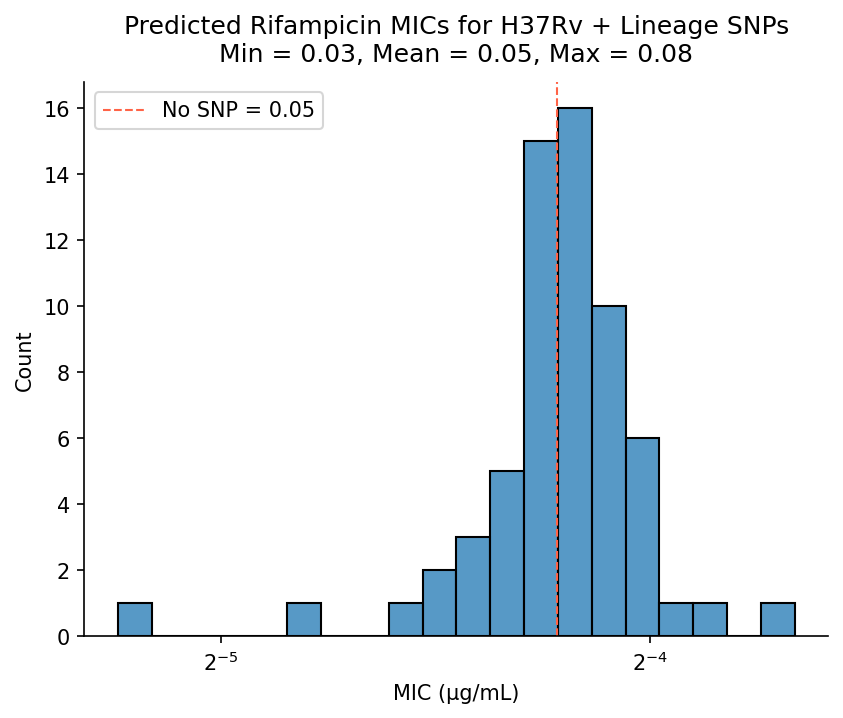

In [49]:
plot_insilico_lineage_pred("Rifampicin", "CNN_log_MIC", save=True)

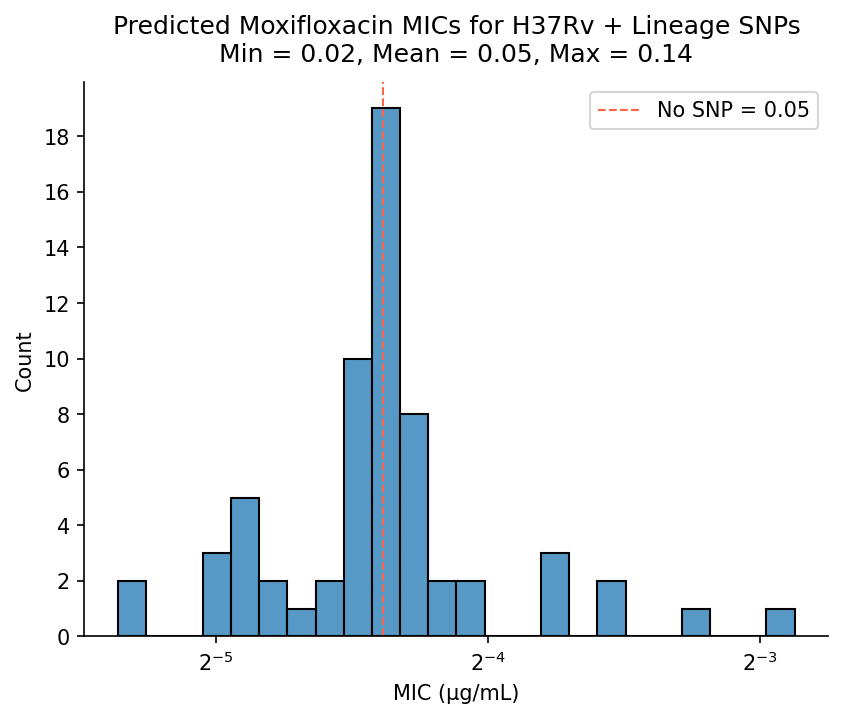

In [50]:
plot_insilico_lineage_pred("Moxifloxacin", "CNN_log_MIC", save=True)

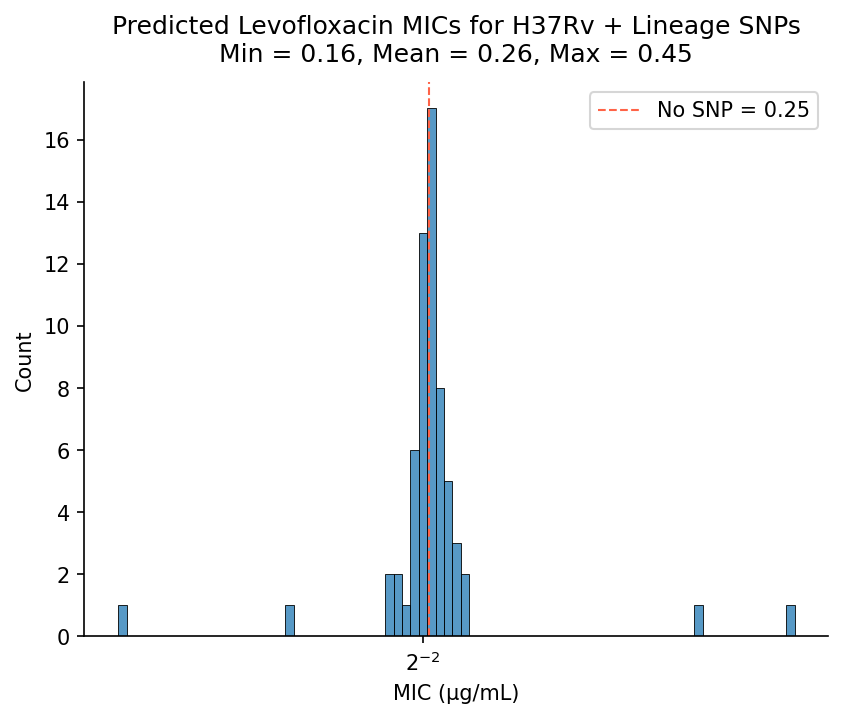

In [51]:
plot_insilico_lineage_pred("Levofloxacin", "CNN_log_MIC", save=True)

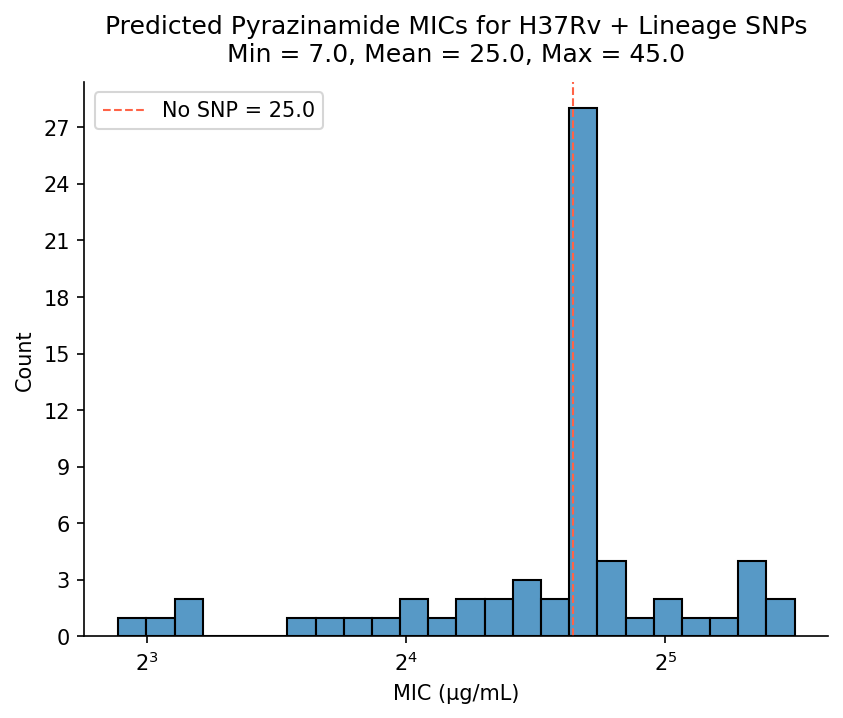

In [57]:
plot_insilico_lineage_pred("Pyrazinamide", "CNN_log_MIC", log_base=2, include_peptide_length=True, save=True)

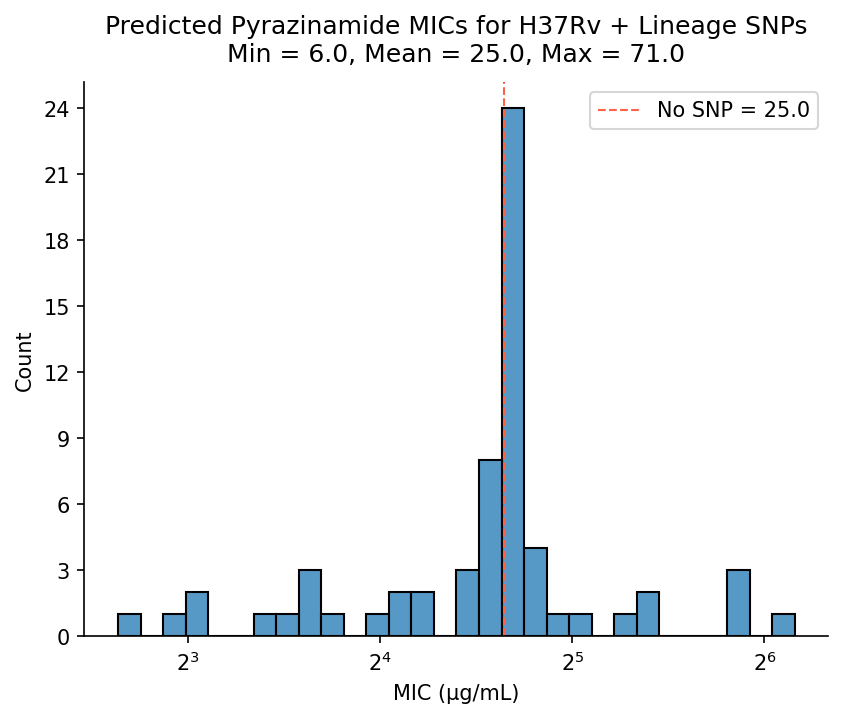

In [58]:
plot_insilico_lineage_pred("Pyrazinamide", "CNN_log_MIC", log_base=2, save=True)

# rpoB Mutations Outside the RRDR

In [197]:
RIF_insilico_annotated.query("gene == 'rpoB' & ~(codon_num >= 426 & codon_num <= 452) & MIC > 0.5")

,drug,WHO_genome_index,confidence,mutation,gene,POS,variant,REF,ALT,REF_len,ALT_len,CNN_log_MIC,MIC,codon_num
6,RIF,761277,1) Assoc w R,rpoB_p.Ile491Phe,rpoB,761277,p.Ile491Phe,A,T,1,1,1.431013,2.696361,491
7,RIF,760314,1) Assoc w R,rpoB_p.Val170Phe,rpoB,760314,p.Val170Phe,G,T,1,1,6.746836,107.398944,170
610,RIF,760305,3) Uncertain significance,rpoB_p.Arg167Cys,rpoB,760305,p.Arg167Cys,C,T,1,1,-0.782696,0.581279,167
1046,RIF,761277,3) Uncertain significance,rpoB_p.Ile491Tyr,rpoB,761277,p.Ile491Tyr,A,T,1,1,3.044604,8.251199,491
1047,RIF,761278,3) Uncertain significance,rpoB_p.Ile491Tyr,rpoB,761278,p.Ile491Tyr,T,A,1,1,3.044604,8.251199,491


# Putative Compensatory Mutations in rpoC

## All rpoC mutations predicted not to increase MIC much

0.026871049874776124

In [111]:
# plt.figure(figsize=(6, 4))
# sns.histplot(data=RIF_insilico_annotated.query("gene=='rpoC'").MIC, log_scale=2)
# plt.axvline(x=RIF_insilico_annotated.query("mutation=='MT_H37Rv'")["MIC"].values[0], color="tomato", linestyle="--", linewidth=0.5, label="H37Rv")

# max_val = np.round(RIF_insilico_annotated.query("gene=='rpoC'").MIC.max(), 2)
# min_val = np.round(RIF_insilico_annotated.query("gene=='rpoC'").MIC.min(), 2)
# mean_val = np.round(RIF_insilico_annotated.query("gene=='rpoC'").MIC.mean(), 2)

# plt.xlabel("MIC (µg/mL)")
# plt.xticks(fontsize="9")
# plt.title(f"Predicted MICs for rpoC Mutations from the 2021 Catalog\nMin = {min_val}, Mean {mean_val}, Max = {max_val}")
# plt.legend()
# sns.despine()

# plt.savefig("Rifampicin/insilico_mutagenesis/rpoC_pred_hist.png", dpi=300)
# # plt.show()

In [97]:
thresh = np.exp2(-5)
RIF_insilico_annotated.query("gene=='rpoC' & MIC < @thresh")

,CNN_log_MIC,MIC,mutation,codon_num,confidence,gene,POS,variant,REF,ALT
1062,-5.033585,0.030531,rpoC_p.Pro601Leu,601,5) Not assoc w R,rpoC,765171.0,p.Pro601Leu,C,T
1070,-5.217803,0.026871,rpoC_p.Arg69Pro,69,5) Not assoc w R,rpoC,763575.0,p.Arg69Pro,G,C


In [100]:
# don't think this is significant, the difference is so small relative to the relevant RIF concentrations
RIF_insilico_annotated.query("gene=='rpoC'").groupby("confidence").MIC.mean()

confidence
3) Uncertain significance    0.060144
5) Not assoc w R             0.053909
Name: MIC, dtype: float64

In [99]:
RIF_insilico_annotated.query("gene=='rpoC'").confidence.value_counts()

confidence
3) Uncertain significance    296
5) Not assoc w R              10
Name: count, dtype: int64

In [ ]:
RIF_insilico_annotated

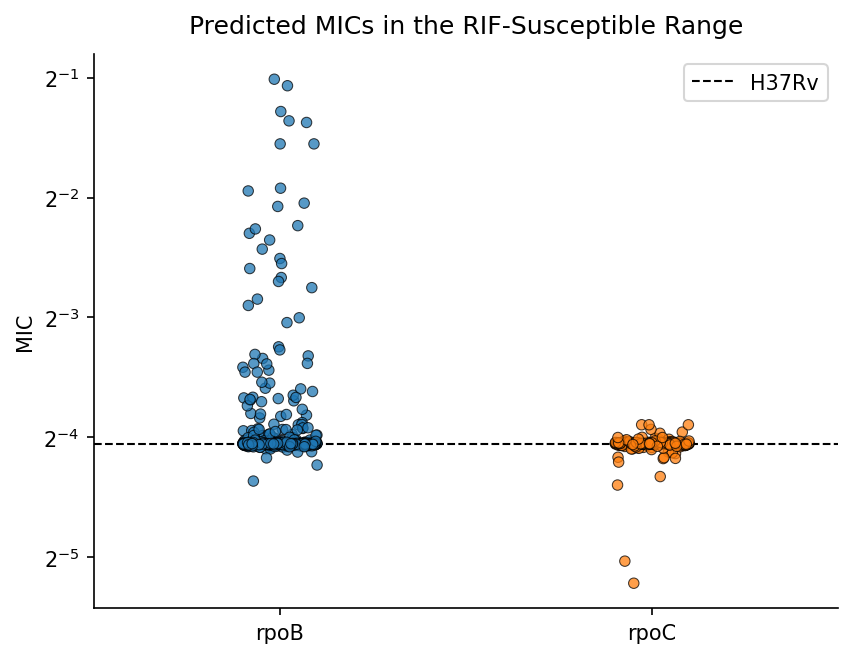

In [110]:
sns.stripplot(data=RIF_insilico_annotated.query("MIC < 0.5 & mutation != 'MT_H37Rv'"),
              x='gene',
              y="MIC",
              hue="gene",
              dodge=False,
              alpha=0.75,
              edgecolor="black",
              linewidth=0.5,
              log_scale=2,
              legend=False
             )

plt.axhline(y=RIF_insilico_annotated.query("mutation=='MT_H37Rv'")["MIC"].values[0], color="black", linestyle="--", linewidth=1, label='H37Rv')
plt.title("Predicted MICs in the RIF-Susceptible Range")
plt.xlabel("")
plt.legend()
sns.despine()
plt.show()

In [113]:
RIF_insilico_annotated.query("gene=='rpoB' & MIC < 0.5").sort_values("MIC", ascending=False)

,CNN_log_MIC,MIC,mutation,codon_num,confidence,gene,POS,variant,REF,ALT
774,-1.011819,0.495921,rpoB_p.Lys422_Thr427del,422,3) Uncertain significance,rpoB,761069.0,p.Lys422_Thr427del,CAAGGAGTTCTTCGGCACC,C
105,-1.066177,0.477583,rpoB_p.Gly426_Thr427del,426,2) Assoc w R - Interim,rpoB,761081.0,p.Gly426_Thr427del,CGGCACC,C
100,-1.281471,0.411376,rpoB_p.Thr427_Leu430del,427,2) Assoc w R - Interim,rpoB,761084.0,p.Thr427_Leu430del,CACCAGCCAGCTG,C
33,-1.359328,0.389764,rpoB_p.Met434Leu,434,2) Assoc w R - Interim,rpoB,761106.0,p.Met434Leu,A,T
66,-1.372821,0.386135,rpoB_p.Met434Ile,434,2) Assoc w R - Interim,rpoB,761108.0,p.Met434Ile,G,T
...,...,...,...,...,...,...,...,...,...,...
260,-4.120531,0.057491,rpoB_c.-122C>T,0,3) Uncertain significance,rpoB,759685.0,c.-122C>T,C,T
1001,-4.123490,0.057373,rpoB_p.Lys944Asn,944,3) Uncertain significance,rpoB,762638.0,p.Lys944Asn,G,T
706,-4.172018,0.055475,rpoB_p.Arg791Cys,791,3) Uncertain significance,rpoB,762177.0,p.Arg791Cys,C,T
863,-4.231538,0.053233,rpoB_c.-134T>G,0,3) Uncertain significance,rpoB,759673.0,c.-134T>G,T,G


In [129]:
def create_ECDF_by_mutation_type(annotated_df, log_base=2, save_fName=None):

    # remove MT_H37Rv because there is no REF and ALT
    annotated_df = annotated_df.query("mutation != 'MT_H37Rv'").reset_index(drop=True)
    annotated_df['REF_len'] = [len(val) for val in annotated_df['REF'].values]
    annotated_df['ALT_len'] = [len(val) for val in annotated_df['ALT'].values]
    
    for i, row in annotated_df.iterrows():

        if "c." in row["mutation"]:
            annotated_df.loc[i, "predicted_effect"] = "upstream noncoding"
        elif "p." in row["mutation"]:

            # missense variant
            if row["REF_len"] == row["ALT_len"]:
                if row["mutation"].endswith('*'):
                    annotated_df.loc[i, "predicted_effect"] = "nonsense"
                else:
                    annotated_df.loc[i, "predicted_effect"] = "missense"
            else:
                # insertions
                if row["ALT_len"] > row["REF_len"]:
                    # inframe: take length difference and if mod 3 = 0
                    if (row["ALT_len"] - row["REF_len"] ) % 3 == 0:
                        annotated_df.loc[i, "predicted_effect"] = "inframe insertion"
                    else:
                        annotated_df.loc[i, "predicted_effect"] = "frameshift"
                else:
                    # inframe: take length difference and if mod 3 = 0
                    if (row["REF_len"] - row["ALT_len"]) % 3 == 0:
                        annotated_df.loc[i, "predicted_effect"] = "inframe deletion"
                    else:
                        annotated_df.loc[i, "predicted_effect"] = "frameshift"

    assert len(annotated_df.loc[pd.isnull(annotated_df["predicted_effect"])]) == 0
    
    df_plot = annotated_df.drop_duplicates("mutation", keep="first")


    fig, ax = plt.subplots(figsize=(4.5, 4))
    sns.ecdfplot(data=df_plot, 
                 x="MIC", 
                 hue="predicted_effect", 
                 hue_order=df_plot.groupby("predicted_effect")["MIC"].mean().sort_values(ascending=False).index.values,
                 palette="colorblind",
                 log_scale=log_base,
                 ax=ax
                )

    plt.xlabel("Predicted MIC (µg/mL)",  fontsize=8)
    plt.ylabel("Proportion",  fontsize=8)
    plt.title(f"Predicted MICs of {len(df_plot)} WHO Catalog Mutations\n", fontsize=10)

    # plt.xlim(df_plot["log_MIC"].min()*1.1, df_plot["log_MIC"].max())

    # fig.legend(labels=df["confidence"].unique())
    sns.move_legend(ax, fontsize=8, title='', loc='lower right')
    # ax.legend(loc='center right', bbox_to_anchor=(1.0, 1.0), fontsize=4, title='')
    plt.xticks(fontsize=8)
    plt.yticks(fontsize=8)
    sns.despine()
    
    if save_fName is None:
        plt.show()
    else:
        plt.savefig(save_fName, dpi=300)

    return annotated_df

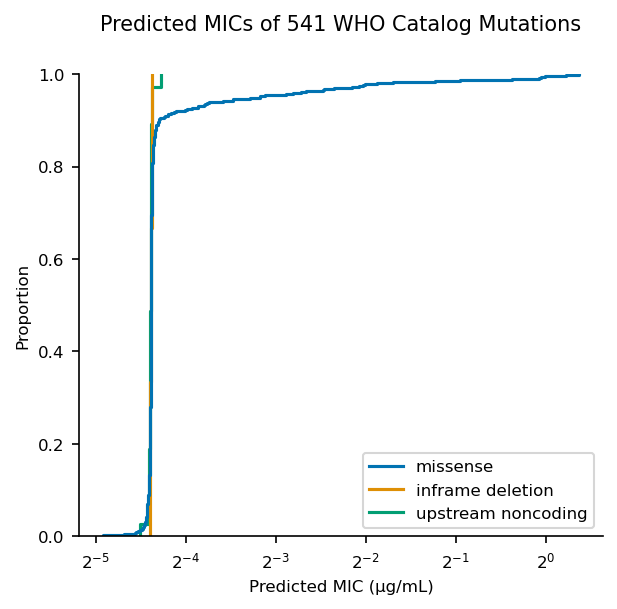

In [130]:
# not important, just discuss because 93% of them are missense mutations, so not much interesting to plot
MXF_insilico_annotated = create_ECDF_by_mutation_type(MXF_insilico_annotated, log_base=2)

In [131]:
MXF_insilico_annotated.predicted_effect.value_counts()

predicted_effect
missense              505
upstream noncoding     37
inframe deletion        3
Name: count, dtype: int64

In [142]:
PZA_insilico_annotated.query("predicted_effect.str.contains('inframe')").sort_values("MIC", ascending=False)[['MIC', 'mutation', 'confidence', 'REF', 'ALT', 'predicted_effect']]

,MIC,mutation,confidence,REF,ALT,predicted_effect
101,59608.811987,pncA_p.Thr160_Ala171del,2) Assoc w R - Interim,GCGCGGCGACGGTGGTATCGGCCGACACACCCGCTGT,G,inframe deletion
96,28846.026842,pncA_p.Asp126_Val130del,2) Assoc w R - Interim,CCACATCGACCTCATC,C,inframe deletion
44,14556.480913,pncA_p.Glu127_Asp129del,1) Assoc w R,CATCGACCTC,C,inframe deletion
99,8854.689483,pncA_p.Gly132_Thr135del,2) Assoc w R - Interim,CGGTGGCAATACC,C,inframe deletion
39,5723.000430,pncA_p.Asp129_Val131del,1) Assoc w R,CGACCACATC,C,inframe deletion
128,824.135645,pncA_p.Ala3_Ile5del,2) Assoc w R - Interim,TGATCAACGC,T,inframe deletion
129,704.077290,pncA_p.Pro54_Asp56del,2) Assoc w R - Interim,GGTCACCCGG,G,inframe deletion
104,395.747657,pncA_p.Gly17_Ala25del,2) Assoc w R - Interim,CGGCGCCACCGGTTACCGCCAGCGAGCC,C,inframe deletion
111,178.798361,pncA_p.Ser74_Pro77del,2) Assoc w R - Interim,CGGGAGTACCGCT,C,inframe deletion
127,135.621820,pncA_p.Gly55del,2) Assoc w R - Interim,CACC,C,inframe deletion


In [144]:
PZA_insilico_annotated.query("predicted_effect == 'missense'").sort_values("MIC", ascending=False)

,CNN_log_MIC,MIC,mutation,codon_num,confidence,gene,POS,variant,REF,ALT,REF_len,ALT_len,predicted_effect
35,9.835639,913.739429,pncA_p.Gln10Arg,10,1) Assoc w R,pncA,2289213.0,p.Gln10Arg,T,C,1,1,missense
340,9.810447,897.922425,pncA_p.Thr135Ala,135,3) Uncertain significance,pncA,2288839.0,p.Thr135Ala,T,C,1,1,missense
228,9.708387,836.595832,pncA_p.Thr160Ala,160,3) Uncertain significance,pncA,2288764.0,p.Thr160Ala,T,C,1,1,missense
5,9.546760,747.930289,pncA_p.Thr135Pro,135,1) Assoc w R,pncA,2288839.0,p.Thr135Pro,T,G,1,1,missense
9,9.546239,747.660238,pncA_p.Leu4Ser,4,1) Assoc w R,pncA,2289231.0,p.Leu4Ser,A,G,1,1,missense
...,...,...,...,...,...,...,...,...,...,...,...,...,...
197,4.525848,23.036474,pncA_p.Thr135Ile,135,3) Uncertain significance,pncA,2288838.0,p.Thr135Ile,G,A,1,1,missense
12,4.516585,22.889039,pncA_p.Cys14Arg,14,1) Assoc w R,pncA,2289202.0,p.Cys14Arg,A,G,1,1,missense
250,4.508297,22.757915,pncA_p.Ala102Val,102,3) Uncertain significance,pncA,2288937.0,p.Ala102Val,G,A,1,1,missense
317,4.441831,21.733235,pncA_p.Phe81Ser,81,3) Uncertain significance,pncA,2289000.0,p.Phe81Ser,A,G,1,1,missense


In [146]:
PZA_insilico_annotated.query("predicted_effect == 'missense' & confidence == '1) Assoc w R' & MIC < 50").sort_values("MIC", ascending=False)

,CNN_log_MIC,MIC,mutation,codon_num,confidence,gene,POS,variant,REF,ALT,REF_len,ALT_len,predicted_effect
56,5.626689,49.408556,pncA_p.Thr142Met,142,1) Assoc w R,pncA,2288817.0,p.Thr142Met,G,A,1,1,missense
66,5.607775,48.765029,pncA_p.Gly132Ala,132,1) Assoc w R,pncA,2288847.0,p.Gly132Ala,C,G,1,1,missense
1,5.565722,47.364098,pncA_p.Asp8Gly,8,1) Assoc w R,pncA,2289219.0,p.Asp8Gly,T,C,1,1,missense
73,5.409050,42.489943,pncA_p.Leu172Pro,172,1) Assoc w R,pncA,2288727.0,p.Leu172Pro,A,G,1,1,missense
94,5.403067,42.314101,pncA_p.Thr142Ala,142,1) Assoc w R,pncA,2288818.0,p.Thr142Ala,T,C,1,1,missense
69,5.396229,42.114038,pncA_p.Asp63Ala,63,1) Assoc w R,pncA,2289054.0,p.Asp63Ala,T,G,1,1,missense
78,5.354948,40.926052,pncA_p.Leu85Pro,85,1) Assoc w R,pncA,2288988.0,p.Leu85Pro,A,G,1,1,missense
38,5.353658,40.889477,pncA_p.Asp8Asn,8,1) Assoc w R,pncA,2289220.0,p.Asp8Asn,C,T,1,1,missense
24,5.306108,39.563770,pncA_p.Val7Leu,7,1) Assoc w R,pncA,2289223.0,p.Val7Leu,C,G,1,1,missense
47,5.305897,39.557984,pncA_p.Val128Gly,128,1) Assoc w R,pncA,2288859.0,p.Val128Gly,A,C,1,1,missense


In [140]:
PZA_insilico_annotated.query("predicted_effect == 'nonsense'").sort_values("MIC", ascending=False)

,CNN_log_MIC,MIC,mutation,codon_num,confidence,gene,POS,variant,REF,ALT,REF_len,ALT_len,predicted_effect
166,11.738578,3417.150325,pncA_p.Gln10*,10,2) Assoc w R - Interim,pncA,2289214.0,p.Gln10*,G,A,1,1,nonsense
105,11.210954,2370.464381,pncA_p.Cys14*,14,2) Assoc w R - Interim,pncA,2289200.0,p.Cys14*,G,T,1,1,nonsense
190,11.101478,2197.241910,pncA_p.Ser18*,18,2) Assoc w R - Interim,pncA,2289189.0,p.Ser18*,G,T,1,1,nonsense
106,11.100072,2195.101599,pncA_p.Glu15*,15,2) Assoc w R - Interim,pncA,2289199.0,p.Glu15*,C,A,1,1,nonsense
118,10.572000,1522.261504,pncA_p.Tyr34*,34,2) Assoc w R - Interim,pncA,2289140.0,p.Tyr34*,G,T,1,1,nonsense
102,10.413456,1363.837459,pncA_p.Tyr41*,41,2) Assoc w R - Interim,pncA,2289119.0,p.Tyr41*,G,T,1,1,nonsense
108,9.787076,883.493677,pncA_p.Tyr64*,64,2) Assoc w R - Interim,pncA,2289050.0,p.Tyr64*,A,T,1,1,nonsense
138,9.727292,847.630682,pncA_p.Trp68*,68,2) Assoc w R - Interim,pncA,2289038.0,p.Trp68*,C,T,1,1,nonsense
174,9.132396,561.209648,pncA_p.Glu91*,91,2) Assoc w R - Interim,pncA,2288971.0,p.Glu91*,C,A,1,1,nonsense
137,9.015460,517.516123,pncA_p.Trp119*,119,2) Assoc w R - Interim,pncA,2288885.0,p.Trp119*,C,T,1,1,nonsense


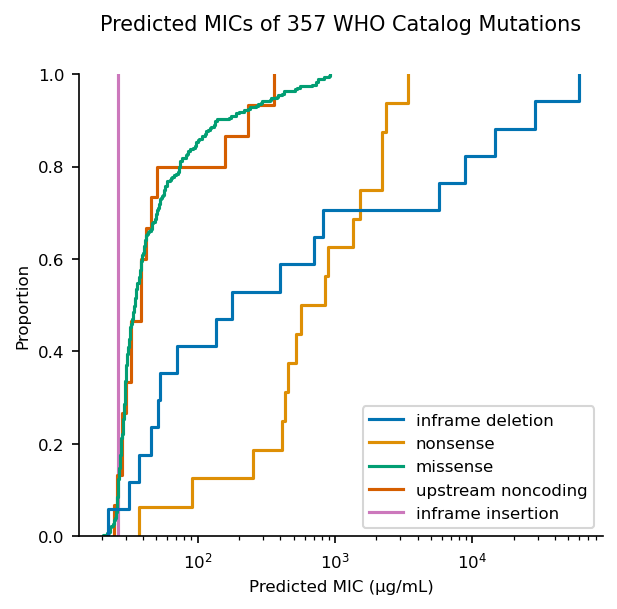

In [133]:
PZA_insilico_annotated = create_ECDF_by_mutation_type(PZA_insilico_annotated, log_base=10)

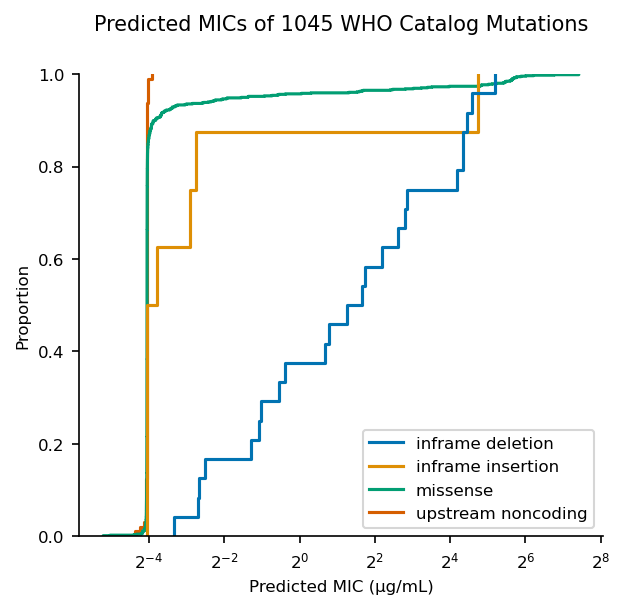

,CNN_log_MIC,MIC,mutation,codon_num,confidence,gene,POS,variant,REF,ALT,REF_len,ALT_len,predicted_effect
0,6.010143,64.451543,rpoB_p.Gln432Lys,432,1) Assoc w R,rpoB,761100.0,p.Gln432Lys,C,A,1,1,missense
1,6.762601,108.579008,rpoB_p.Gln432Pro,432,1) Assoc w R,rpoB,761101.0,p.Gln432Pro,A,C,1,1,missense
2,3.975927,15.735237,rpoB_p.Ser441Leu,441,1) Assoc w R,rpoB,761128.0,p.Ser441Leu,C,T,1,1,missense
3,5.486880,44.845148,rpoB_p.Gln432Leu,432,1) Assoc w R,rpoB,761101.0,p.Gln432Leu,A,T,1,1,missense
4,4.747486,26.861828,rpoB_p.Phe433dup,433,1) Assoc w R,rpoB,761102.0,p.Phe433dup,A,ATTC,1,4,inframe insertion
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1070,-5.217803,0.026871,rpoC_p.Arg69Pro,69,5) Not assoc w R,rpoC,763575.0,p.Arg69Pro,G,C,1,1,missense
1071,-4.057892,0.060042,rpoC_p.Pro906Ala,906,5) Not assoc w R,rpoC,766085.0,p.Pro906Ala,C,G,1,1,missense
1072,-4.060262,0.059943,rpoC_p.Asp271Gly,271,5) Not assoc w R,rpoC,764181.0,p.Asp271Gly,A,G,1,1,missense
1073,-4.001813,0.062421,rpoC_p.Ala172Val,172,5) Not assoc w R,rpoC,763884.0,p.Ala172Val,C,T,1,1,missense


In [136]:
create_ECDF_by_mutation_type(RIF_insilico_annotated)#, "Rifampicin/insilico_mutagenesis/mutations_by_type.png")

# Plot Distribution of Predicted MICs

In [147]:
def plot_ECDF(df, log_base=2, col="MIC", saveName=None):

    df = df.loc[~pd.isnull(df["confidence"])].drop_duplicates("mutation")
    print(df.groupby("confidence")[col].agg(['mean', 'median']))
    
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.ecdfplot(data=df, 
                 x=col, 
                 hue="confidence", 
                 hue_order=np.sort(df["confidence"].unique()),
                 palette="colorblind", 
                 ax=ax,
                 log_scale=log_base, # for PZA, set to 10 to spread out the graph
                 zorder=3
                )
    
    # ax.set_yticks(ticks=ax.get_yticks(), labels=(ax.get_yticks()*100).astype(int))
    ax.set_yticks(ticks=[0.25, 0.5, 0.75, 1], labels=[25, 50, 75, 100])

    for percentile in [0.25, 0.5, 0.75]:
        plt.axhline(y=percentile, linestyle='--', color="lightgray", linewidth=1, zorder=0)

    plt.xlabel("Predicted MIC (µg/mL)",  fontsize=8)
    plt.ylabel("Percentile",  fontsize=8)
    plt.title(f"Predicted MICs of {len(df.mutation.unique())} WHO Catalog Mutations\n", fontsize=10)
    
    y = df[col]
    plt.xlim(y.min()*1.1, y.max()*1.1)

    # fig.legend(labels=df["confidence"].unique())
    sns.move_legend(ax, fontsize=8, title='', loc='upper right', bbox_to_anchor=(1.5, 0.6))
    # ax.legend(loc='center right', bbox_to_anchor=(1.0, 1.0), fontsize=4, title='')
    plt.xticks(fontsize=8)
    plt.yticks(fontsize=8)
    sns.despine()
    
    if saveName is not None:
        plt.savefig(saveName, dpi=300, bbox_inches='tight')
    else:
        plt.show()

                                   mean     median
confidence                                        
1) Assoc w R                 352.152426  44.927020
2) Assoc w R - Interim      1277.974080  53.026551
3) Uncertain significance     55.409709  32.187642
4) Not assoc w R - Interim    35.594589  27.657771


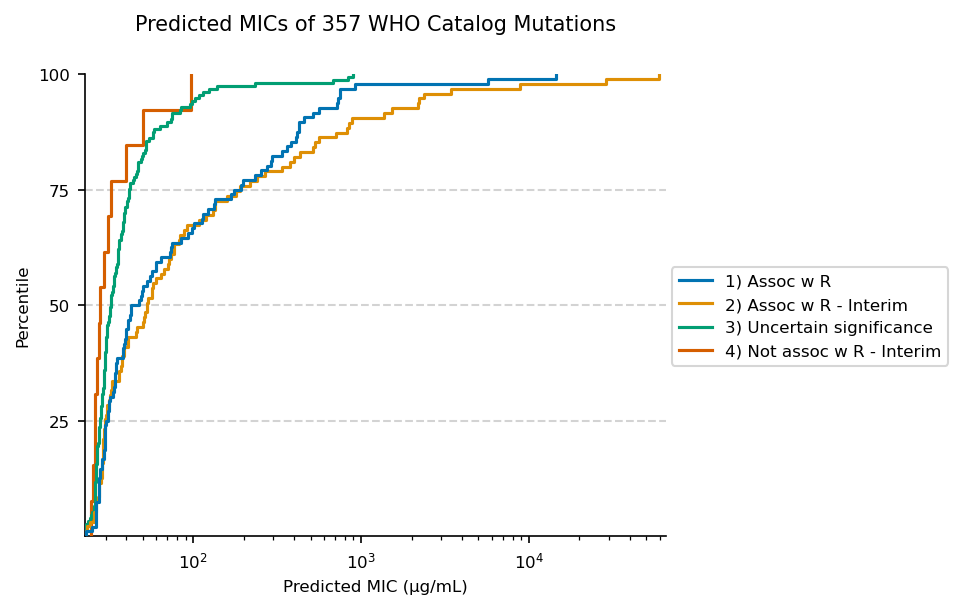

In [148]:
plot_ECDF(PZA_insilico_annotated, log_base=10, saveName="Pyrazinamide/insilico_mutagenesis/WHO_pncA_ECDF.png")

In [149]:
who_variants.query("gene=='pncA'").confidence.unique()

array(['1) Assoc w R', '2) Assoc w R - Interim',
       '3) Uncertain significance', '4) Not assoc w R - Interim'],
      dtype=object)

                                mean    median
confidence                                    
1) Assoc w R                0.728039  0.770783
2) Assoc w R - Interim      0.124853  0.102680
3) Uncertain significance   0.053687  0.047853
4) Not assoc w R - Interim  0.178650  0.178650
5) Not assoc w R            0.050252  0.047454


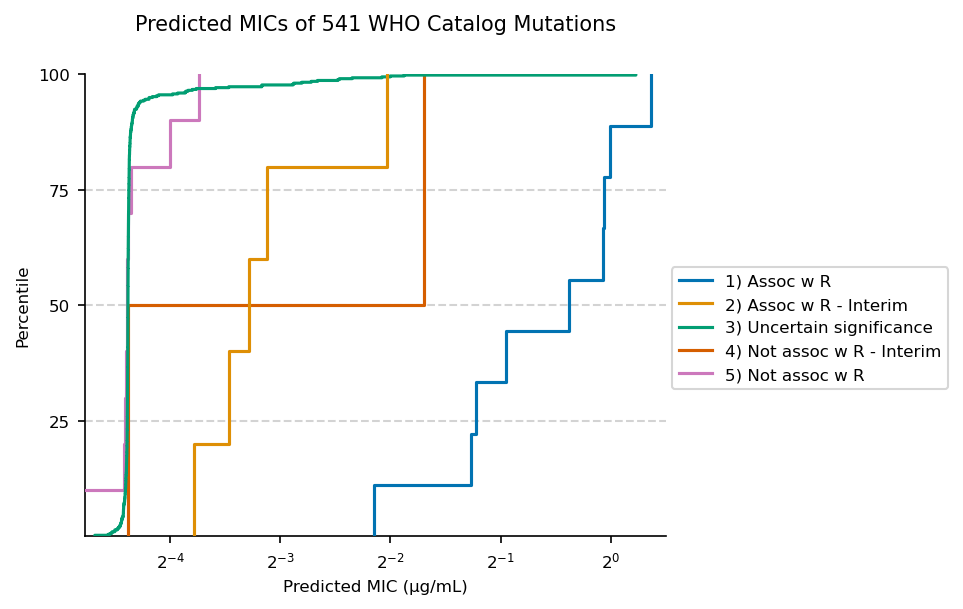

In [95]:
plot_ECDF(MXF_insilico_annotated, saveName="Moxifloxacin/insilico_mutagenesis/WHO_gyrBA_ECDF.png")

In [94]:
MXF_insilico_annotated.loc[~pd.isnull(MXF_insilico_annotated['confidence'])].query("confidence.str.contains('4')")

,CNN_log_MIC,MIC,mutation,codon_num,confidence,gene,POS,variant,REF,ALT,REF_len,ALT_len,predicted_effect
533,-1.692260,0.309442,gyrA_p.Ala90Gly,90,4) Not assoc w R - Interim,gyrA,7570.0,p.Ala90Gly,C,G,1,1,missense_variant
534,-4.385074,0.047859,gyrA_p.Thr80Ala,80,4) Not assoc w R - Interim,gyrA,7539.0,p.Thr80Ala,A,G,1,1,missense_variant


In [81]:
solo_results = pd.read_csv("/home/sak0914/who-analysis/results/SOLO_Final_Aug2023.csv", header=[1]).query("tier==1")

In [83]:
solo_results.query("variant in ['gyrA_p.Ala90Gly', 'gyrA_p.Thr80Ala']")

,drug,gene,mutation,variant,tier,effect,genomic position,algorithm_pass,Present_SOLO_SR,Present_SOLO_R,...,Additional grading criteria applied,FINAL CONFIDENCE GRADING,Comment,CHANGES vs ver1,"Relaxed thresholds simulation (BDQ_Rv0678, CFZ_Rv0678, INH_katG, DLM_ddn/fbiA/fbiB/fbiC/fgd1/Rv2983)",Silent mutation,Listed in abridged tables,Additional grading,Footnote,CHANGES vs ver1.1
29328,Levofloxacin,gyrA,p.Ala90Gly,gyrA_p.Ala90Gly,1,missense_variant,NaN,0.0,0.0,0.0,...,Literature evidence (PMID 28137812),4) Not assoc w R - Interim,NaN,No change,NaN,NaN,yes,Lit. (PMID 28137812),NaN,1
29682,Levofloxacin,gyrA,p.Thr80Ala,gyrA_p.Thr80Ala,1,missense_variant,NaN,0.0,0.0,0.0,...,NaN,5) Not assoc w R,NaN,UP from NotAwRI to NotAwR,NaN,NaN,yes,NaN,NaN,4
33235,Moxifloxacin,gyrA,p.Ala90Gly,gyrA_p.Ala90Gly,1,missense_variant,NaN,0.0,0.0,0.0,...,Literature evidence (PMID 28137812),4) Not assoc w R - Interim,NaN,No change,NaN,NaN,yes,Lit. (PMID 28137812),NaN,1
33540,Moxifloxacin,gyrA,p.Thr80Ala,gyrA_p.Thr80Ala,1,missense_variant,NaN,0.0,0.0,0.0,...,Literature evidence (PMID 28137812),4) Not assoc w R - Interim,NaN,No change,NaN,NaN,yes,Lit. (PMID 28137812),NaN,1


In [75]:
MXF_insilico_annotated.query("codon_num==90 & gene=='gyrA'")

,CNN_log_MIC,MIC,mutation,codon_num,confidence,gene,POS,variant,REF,ALT
2,-0.364727,0.776616,gyrA_p.Ala90Val,90,1) Assoc w R,gyrA,7570.0,p.Ala90Val,C,T
533,-0.778663,0.582907,gyrA_p.Ala90Gly,90,4) Not assoc w R - Interim,gyrA,7570.0,p.Ala90Gly,C,G


In [76]:
MXF_insilico_annotated.query("codon_num==80")

,CNN_log_MIC,MIC,mutation,codon_num,confidence,gene,POS,variant,REF,ALT
534,-1.713533,0.304912,gyrA_p.Thr80Ala,80,4) Not assoc w R - Interim,gyrA,7539.0,p.Thr80Ala,A,G


                                mean     median
confidence                                     
1) Assoc w R               36.806966  28.679853
2) Assoc w R - Interim      8.053326   0.203380
3) Uncertain significance   0.075063   0.060231
5) Not assoc w R            0.057145   0.060188


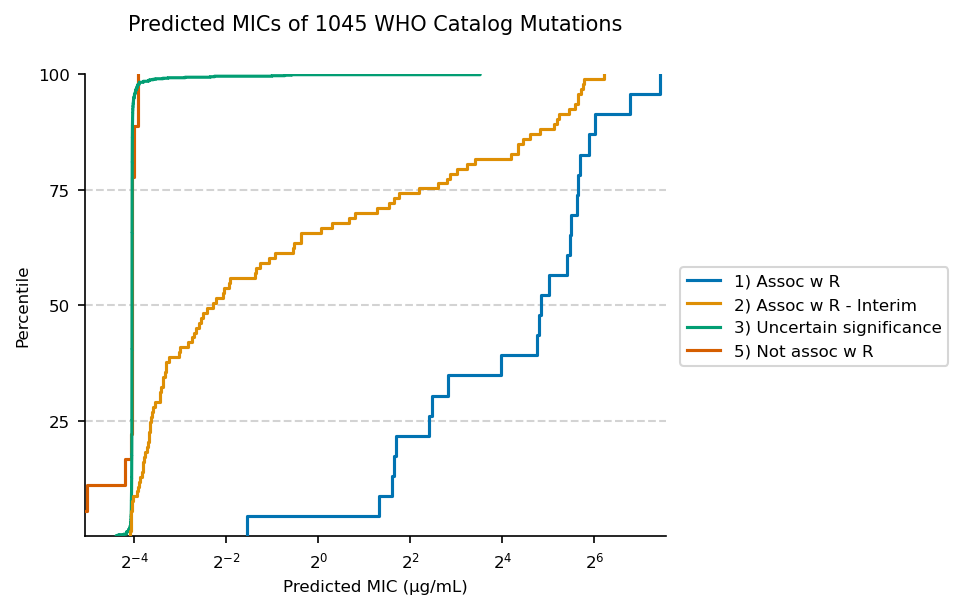

In [150]:
plot_ECDF(RIF_insilico_annotated, saveName="Rifampicin/insilico_mutagenesis/WHO_rpoBC_ECDF.png")

In [155]:
RIF_insilico_annotated.query("MIC < 0.5 & confidence == '1) Assoc w R'")

,CNN_log_MIC,MIC,mutation,codon_num,confidence,gene,POS,variant,REF,ALT
21,-1.551492,0.341157,rpoB_p.Ser441Gln,441,1) Assoc w R,rpoB,761127.0,p.Ser441Gln,T,C
22,-1.551492,0.341157,rpoB_p.Ser441Gln,441,1) Assoc w R,rpoB,761128.0,p.Ser441Gln,C,A


In [156]:
df_RIF = pd.read_csv(os.path.join(data_dir, "RIF", "data_for_model.csv"))

In [157]:
df_RIF.query()

,ROLLINGDB_ID,BIOSAMPLE_ACCESSION,ID,ISOLATION_LOCATION,DB_OF_ORIGIN,STUDY_NAME,STUDY_PMID,TESTING_LOCATION,MEDIA,RIF,RIF_lower_bound,RIF_midpoint,RIF_upper_bound,RIF_quality,Path,Coll2014,Binary,Lineage,category
0,ERR4810491,ERS5298518,site.02.subj.0002.lab.2014222005.iso.1,NaN,CRyPTIC,The CRyPTIC Consortium,https://doi.org/10.1101/2021.09.14.460274(pre-...,Not specified in paper,m7h10,<=0.06,0.00,0.03,0.06,HIGH,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF/...,4.5,0,4,original_train_set
1,ERR4810493,ERS5298520,site.02.subj.0004.lab.2014222010.iso.1,NaN,CRyPTIC,The CRyPTIC Consortium,https://doi.org/10.1101/2021.09.14.460274(pre-...,Not specified in paper,m7h10,0.12,0.06,0.09,0.12,HIGH,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF/...,4.4.2,0,4,original_train_set
2,ERR4810494,ERS5298521,site.02.subj.0005.lab.2014222011.iso.1,NaN,CRyPTIC,The CRyPTIC Consortium,https://doi.org/10.1101/2021.09.14.460274(pre-...,Not specified in paper,m7h10,0.12,0.06,0.09,0.12,HIGH,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF/...,4.5,0,4,original_train_set
3,ERR4810495,ERS5298522,site.02.subj.0006.lab.2014222013.iso.1,NaN,CRyPTIC,The CRyPTIC Consortium,https://doi.org/10.1101/2021.09.14.460274(pre-...,Not specified in paper,m7h10,0.12,0.06,0.09,0.12,HIGH,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF/...,2.2.2,0,2,original_train_set
4,ERR4810497,ERS5298524,site.02.subj.0007.lab.2014222016.iso.1,NaN,CRyPTIC,The CRyPTIC Consortium,https://doi.org/10.1101/2021.09.14.460274(pre-...,Not specified in paper,m7h10,<=0.06,0.00,0.03,0.06,HIGH,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF/...,4.5,0,4,original_test_set
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8996,SAMEA3558181,SAMEA3558181,1773.8074,NaN,PATRIC_20191206,Phelan 2016 BMC Med,27005572.0,ITM,m7h10,40-80,40.00,60.00,80.00,HIGH,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF/...,2.2.2,1,2,original_train_set
8997,SAMEA3558209,SAMEA3558209,1773.8102,NaN,PATRIC_20191206,Phelan 2016 BMC Med,27005572.0,ITM,m7h10,>120,120.00,120.00,inf,HIGH,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF/...,4.1.2.1,1,4,original_train_set
8998,SAMEA3558222,SAMEA3558222,1773.8115,NaN,PATRIC_20191206,Phelan 2016 BMC Med,27005572.0,ITM,m7h10,10-20,10.00,15.00,20.00,HIGH,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF/...,4.1.2.1,1,4,original_train_set
8999,SAMEA3558187,SAMEA3558187,1773.8080,NaN,PATRIC_20191206,Phelan 2016 BMC Med,27005572.0,ITM,m7h10,>120,120.00,120.00,inf,HIGH,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF/...,4.8,1,4,original_train_set


# Association Between Predicted MIC and Saliency Score

In [70]:
RIF_rpoABC_scores = sparse.load_npz(os.path.join(results_path, "RIF_rpoABC/saliency/quant/genetic_scores_unpooled_nuc.npy.npz")).todense()
BASE_TO_COLUMN = {'A': 0, 'C': 1, 'T': 2, 'G': 3, '-': 4}

RIF_rpoABC_saliency_df = pd.read_csv("Rifampicin/rpoABC_saliency_results.csv")
RIF_rpoABC_saliency_df["Pos"] = [int(float(val)) if val.replace('.', '').isnumeric() else val for val in RIF_rpoABC_saliency_df["Pos"].values]

In [36]:
def get_max_min_scores_for_pos(idx, scores_matrix, alt_nuc):
    
    max_scores_dict = dict(zip(BASE_TO_COLUMN.keys(), np.max(scores_matrix[:, :, idx, 0], axis=0)))
    min_scores_dict = dict(zip(BASE_TO_COLUMN.keys(), np.min(scores_matrix[:, :, idx, 0], axis=0)))

    # score for the actual alternative allele
    max_allele_score = max_scores_dict[alt_nuc]
    min_allele_score = min_scores_dict[alt_nuc]
    
    return max_allele_score, min_allele_score

In [88]:
RIF_combined.shape, len(RIF_combined.mutation.unique())

((1076, 22), 1046)

In [91]:
pos = 761100
RIF_combined.loc[RIF_combined["POS"]==pos, "Max_Sig"].values[0] == 1

True

In [92]:
RIF_combined

,CNN_log_MIC,MIC,mutation,codon_num,drug,WHO_genome_index,confidence,gene,POS,variant,...,REF_len,ALT_len,Gene,Max,Min,Max_Sig,Min_Sig,WHO,Coll_2014,Freschi_2020
0,5.851739,57.749598,rpoB_p.Gln432Lys,432,RIF,761100,1) Assoc w R,rpoB,761100.0,p.Gln432Lys,...,1.0,1.0,rpoBC,2.408599,-0.160379,1.0,1.0,1.0,0.0,0.0
1,6.649882,100.418551,rpoB_p.Gln432Pro,432,RIF,761101,1) Assoc w R,rpoB,761101.0,p.Gln432Pro,...,1.0,1.0,rpoBC,5.036633,-0.496792,1.0,1.0,1.0,0.0,0.0
2,3.484618,11.193723,rpoB_p.Ser441Leu,441,RIF,761128,1) Assoc w R,rpoB,761128.0,p.Ser441Leu,...,1.0,1.0,rpoBC,2.639750,0.000000,1.0,0.0,1.0,0.0,0.0
3,5.931672,61.039515,rpoB_p.Gln432Leu,432,RIF,761101,1) Assoc w R,rpoB,761101.0,p.Gln432Leu,...,1.0,1.0,rpoBC,5.036633,-0.496792,1.0,1.0,1.0,0.0,0.0
4,4.832014,28.482692,rpoB_p.Phe433dup,433,RIF,761102,1) Assoc w R,rpoB,761102.0,p.Phe433dup,...,1.0,4.0,rpoBC,3.493368,-0.155746,1.0,1.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1071,-4.099459,0.058336,rpoC_p.Pro906Ala,906,RIF,766085,5) Not assoc w R,rpoC,766085.0,p.Pro906Ala,...,1.0,1.0,rpoBC,0.000000,-0.026943,0.0,1.0,0.0,0.0,0.0
1072,-4.098166,0.058389,rpoC_p.Asp271Gly,271,RIF,764181,5) Not assoc w R,rpoC,764181.0,p.Asp271Gly,...,1.0,1.0,rpoBC,0.000000,-0.036219,0.0,1.0,0.0,0.0,0.0
1073,-4.034865,0.061008,rpoC_p.Ala172Val,172,RIF,763884,5) Not assoc w R,rpoC,763884.0,p.Ala172Val,...,1.0,1.0,rpoBC,0.034771,0.000000,1.0,0.0,0.0,0.0,0.0
1074,-4.034865,0.061008,rpoC_p.Ala172Val,172,RIF,763885,5) Not assoc w R,rpoC,763885.0,p.Ala172Val,...,1.0,1.0,rpoBC,0.007297,0.000000,1.0,0.0,0.0,0.0,0.0


In [270]:
def get_saliency_score_single_mutation(drug, mutation, saliency_df, seq_df, saliency_scores_by_nuc):

    vcf_reader = vcf.Reader(filename=f"/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/{drug}/inSilico_analysis/synthetic_VCF/{mutation}.vcf")

    scores_lst = []
    
    for record in vcf_reader:
        pos = record.POS
        alt = str(record.ALT[0])

        # if site has a significant positive score and an insignificant negative score, get it
        if saliency_df.loc[saliency_df["Pos"]==pos, "Max_Sig"].values[0] == 1:# and saliency_df.loc[saliency_df["Pos"]==pos, "Min_Sig"].values[0] == 0:

            # keep only alleles that are present in at least 2 isolates (there are some in only 1)
            if len(seq_df.loc[seq_df[pos] == alt]) > 1:

                idx = saliency_df.query("Pos==@pos").index.values[0] 
                max_scores = np.max(saliency_scores_by_nuc[:, :, idx, 0], axis=0)
                max_scores_dict = dict(zip(BASE_TO_COLUMN.keys(), max_scores))
        
                assert seq_df.loc['MT_H37Rv', pos] == record.REF
        
                scores_lst.append(max_scores_dict[alt])

            else:
                scores_lst.append(0)

        # if not, set it as 0
        else:
            scores_lst.append(0)
            
    return np.mean(scores_lst)



def combine_score_across_multiple_sites(saliency_df, multi_site_str):

    split_sites = multi_site_str.split(",")
    sig_score_sites = []

    for site in split_sites:

        site = int(site)
        if len(saliency_df.query("POS==@site & Max_Sig == 1")) > 0:
            max_score = saliency_df.query("POS==@site & Max_Sig == 1").Max.values[0]
        else:
            max_score = None

        if len(saliency_df.query("POS==@site & Min_Sig == 1")) > 0:
            min_score = saliency_df.query("POS==@site & Min_Sig == 1").Min.values[0]
        else:
            min_score = None

        # if both Max and Min are significant, take the mean
        if max_score is not None:
            if min_score is not None:
                sig_score_sites.append(np.mean([max_score, min_score]))
            else:
                sig_score_sites.append(max_score)
        else:
            if min_score is not None:
                sig_score_sites.append(min_score)
            else:
                sig_score_sites.append(0)
    
    # take the sum of significant sites because the effects are likely additive (mean will underestimate effects)
    return np.sum(sig_score_sites)
    
    
    
def plot_pred_MIC_by_saliency(drug, insilico_pred_df, saliency_df, seq_df, saliency_scores_by_nuc, saveName=None):
    '''
    Only plots SNPs and missense mutations for simplicity. For MNPs, would have to combine saliency scores across nucleotides,  
    '''

    df_combined = insilico_pred_df.merge(saliency_df, left_on='POS', right_on='Pos', how='left').query("mutation != 'MT_H37Rv'").reset_index(drop=True) # exclude MT_H37Rv
    del df_combined['Pos']
    
    for i, row in df_combined.iterrows():
        # ignore indels for now
        if "del" not in row["mutation"] and "ins" not in row["mutation"] and "dup" not in row["mutation"]:
            df_combined.loc[i, "saliency_score"] = get_saliency_score_single_mutation(drug, row["mutation"], saliency_df, seq_df, saliency_scores_by_nuc)
            
    # NaNs are indels, 0 scores are no significant saliency score, so exclude both before plotting
    # also exclude MNPs because of having to combine saliency scores across sites
    plot_df = insilico_pred_df.loc[~pd.isnull(insilico_pred_df["saliency_score"])].query("saliency_score > 0")# & ~genome_index.str.contains(',')")
        
    fig, ax = plt.subplots()
    sns.scatterplot(data=plot_df,
                    x="saliency_score",
                    y="CNN_log_MIC",
                    hue="confidence",
                    palette="colorblind",
                    alpha=0.8,
                    edgecolor="black",
                    linewidth=0.5,
                    s=30,
                    ax=ax
                   )
    
    plt.axhline(y=-1, label="CC = 0.5 µg/mL", color="black", linestyle="--", linewidth=0.8, zorder=0)
    
    rho, pval = st.spearmanr(plot_df["saliency_score"], plot_df['CNN_log_MIC'])
    plt.xlabel("Max. Saliency Score")
    plt.ylabel("Predicted log2-MIC")
    plt.title(f"{len(plot_df)} SNP Missense Mutations, Spearman R = {np.round(rho, 2)}, pval = {np.round(pval, 4)}")
    # plt.legend()
    
    legend = plt.legend(title="", fontsize='7')
    
    #change the marker size manually for both lines
    for i, _ in enumerate(plot_df.confidence.unique()):
        legend.legendHandles[i]._sizes = [15]
    #ax.set_yticks(ticks=ax.get_yticks(), labels=np.round(np.exp2(ax.get_yticks()), 2))
    sns.despine()

    if saveName is None:
        plt.show()
    else:
        if not os.path.isdir(os.path.dirname(saveName)):
            os.makedirs(os.path.dirname(saveName))
        plt.savefig(saveName, dpi=300)

    return insilico_pred_df

In [39]:
RIF_pred = pd.read_csv("../analysis/Rifampicin/insilico_mutagenesis/rpoBC_WHO_predictions.csv")

RIF_pred = plot_pred_MIC_by_saliency("RIF", RIF_pred, RIF_rpoABC_df, rpoABC_seqDict['rpoBC'], RIF_rpoABC_scores, #saveName="../analysis/Rifampicin/insilico_mutagenesis/predictions_vs_saliency.png"
                                    )

,log_MIC,mutation,confidence,genome_index,MIC
0,4.410317,rpoB_p.Gln432Lys,1) Assoc w R,761100,21.263637
1,4.144792,rpoB_p.Gln432Pro,1) Assoc w R,761101,17.689135
2,2.688850,rpoB_p.Ser441Leu,1) Assoc w R,761128,6.447993
3,3.664820,rpoB_p.Gln432Leu,1) Assoc w R,761101,12.682964
4,2.804300,rpoB_p.Phe433dup,1) Assoc w R,761102,6.985193


In [42]:
for i, row in df_rif_pred.iterrows():
    
    vcf_reader = vcf.Reader(filename=os.path.join(vcf_dir, f"{row['mutation']}.vcf"))
    combined_max_score = []
    combined_min_score = []
    
    #print(row['mutation'])
    
    for record in vcf_reader:

        pos = record.POS
        ref_allele = str(record.REF)
        alt_allele = str(record.ALT[0])

        # index in the scores matrix
        idx = RIF_rpoBC_saliency_df.loc[RIF_rpoBC_saliency_df["Pos"]==pos].index.values[0]
            
        if len(ref_allele) == 1:
            
            # SNP
            if len(alt_allele) == 1:
                
                assert h37Rv_seq.seq[pos-1] == record.REF
                # print(pos, record.REF, alt_allele)
                max_allele_score, min_allele_score = get_max_min_scores_for_pos(idx, RIF_rpoBC_scores, alt_allele)
                
                # update the running totals -- single score added for each record
                combined_max_score.append(max_allele_score)
                combined_min_score.append(min_allele_score)
            
            # insertion
            else:
                for k, nuc in enumerate(alt_allele):
                    adj_idx = idx + k + 1
                    max_allele_score, min_allele_score = get_max_min_scores_for_pos(adj_idx, RIF_rpoBC_scores, nuc)
                    combined_max_score.append(max_allele_score)
                    combined_min_score.append(min_allele_score)
                    
        else:
            
            # deletion   
            if len(alt_allele) == 1:
                                
                # the first nucleotide is the alternative allele. Then the rest are gap characters
                for k, nuc in enumerate(ref_allele):
                    
                    adj_idx = idx + k + 1
                    
                    if k == 0:
                        nuc = alt_allele
                    else:
                        nuc = "-"
                    
                    max_allele_score, min_allele_score = get_max_min_scores_for_pos(adj_idx, RIF_rpoBC_scores, nuc)
                    combined_max_score.append(max_allele_score)
                    combined_min_score.append(min_allele_score)
               
            # complex indel
            else:
                
                print(f"Did not process {pos}, {ref_allele}, {alt_allele}")
                combined_max_score = [np.nan]
                combined_min_score = [np.nan]
                
#                 if ref_allele[0] == alt_allele[0]:
                    
#                     print(pos, ref_allele, alt_allele)
                    
#                     # insertion
#                     if len(alt_allele) > len(ref_allele):
                        
#                         for k, nuc in enumerate(ref_allele):
#                             adj_idx = idx + k + 1
                           
#                     # deletion
#                     if len(ref_allele) > len(alt_allele):
                    
#                         for k, nuc in enumerate(alt_allele):
                    
#                 else:
#                     print(f"Did not process {pos}, {ref_allele}, {alt_allele}")

    df_rif_pred.loc[i, ["Max_score", "Min_score"]] = [np.mean(combined_max_score), np.mean(combined_min_score)]
    
    
# for i, row in df_rif_pred.iterrows():
    
#     if row["Max_score"] > 0:
#         if row["Min_score"] < 0:
#             df_rif_pred.loc[i, "Mean_score"] = np.mean([row["Max_score"], row["Mean_score"]])
#         else:
#             df_rif_pred.loc[i, "Mean_score"] = row["Max_score"]
#     else:
#         if row["Min_score"] < 0:
#             df_rif_pred.loc[i, "Mean_score"] = row["Min_score"]
#         else:
#             df_rif_pred.loc[i, "Mean_score"] = 0

Did not process 761099, CCAATTCATGGAC, CCAT
Did not process 761105, CATGGACCAGAAC, CATC
Did not process 761084, CACCAGCCAG, CAAA
Did not process 761108, GGACCAG, GGAG


In [2]:


# def add_saliency_scores(plot_df):
    
#     for i, row in plot_df.iterrows():

#         # combine scores across sites for indels
#         if len(row["REF"]) > 1 or len(row["ALT"]) > 1:

#             pos = row["POS"]
#             search_idx = plot_df.query("POS==@pos").index.values[0]
#             diff_len = np.abs(len(row["REF"]) - len(row["ALT"]))

#             max_sig_df = plot_df.iloc[search_idx:search_idx+diff_len].query("Max_Sig==1")
#             if len(max_sig_df) > 0:
#                 max_score = np.max(max_sig_df["Max"])
#             else:
#                 max_score = 0

#             min_sig_df = plot_df.iloc[search_idx:search_idx+diff_len].query("Min_Sig==1")
#             if len(min_sig_df) > 0:
#                 min_score = np.min(min_sig_df["Min"])
#             else:
#                 min_score = 0

#             # because we're considering multiple sites, take the sum
#             plot_df.loc[i, "saliency_score"] = np.sum([max_score, min_score])
            
#         else:
#             if "," in row["genome_index"]:
#                 plot_df.loc[i, "saliency_score"] = combine_score_across_multiple_sites(plot_df, row["genome_index"])
#             else:
#                 if row["Max_Sig"] == 1 and row["Min_Sig"] == 0:
#                     plot_df.loc[i, "saliency_score"] = row["Max"]

#                 elif row["Max_Sig"] == 0 and row["Min_Sig"] == 1:
#                     plot_df.loc[i, "saliency_score"] = row["Min"]

#                 elif row["Max_Sig"] == 1 and row["Min_Sig"] == 1:
#                     plot_df.loc[i, "saliency_score"] = np.mean([row["Max"], row["Min"]])
#                 else:
#                     plot_df.loc[i, "saliency_score"] = 0
                            
#     # if a mutation requires more than one SNV, then there will be multiple rows. But the saliency scores have now been combined, so drop the duplicates 
#     # (they will have the same value in the saliency_score field)
#     plot_df = plot_df.drop_duplicates("mutation", keep="first").reset_index(drop=True)

#     # nothing should be NaN anywhere in the dataframe
#     #assert len(plot_df.dropna()) == len(plot_df)
#     print(plot_df.shape)
    
#     return plot_df

# def get_saliency_scores_to_plot_saliency(pred_df,
#                                          vcf_df,
#                                          saliency_df,
#                                         ):
    
#     # present in both dataframes, so remove it before merging
#     if "confidence" in saliency_df.columns:
#         del saliency_df["confidence"]
    
#     if "POS" not in pred_df.columns:
#         pred_df = pred_df.merge(vcf_df[["mutation", "gene", "POS", "REF", "ALT"]], on="mutation", how="left").reset_index(drop=True)
    
#     # clean up the columns
#     del_cols = ["saliency_score", "drug", "WHO", "Lineage_SNP"]

#     for col in del_cols:
#         if col in pred_df.columns:
#             del pred_df[col]
            
#     if "POS" not in saliency_df.columns:
#         saliency_df["POS"] = [int(float(val)) if val.replace(".", "").isnumeric() else val for val in saliency_df["Pos"].values]
    
#     pred_df = pred_df.merge(saliency_df, on="POS", how="left")
#     pred_df = add_saliency_scores(pred_df)
#     return pred_df

In [161]:
print(df_rif_pred.shape)
RIF_rpoBC_saliency = pd.read_csv("Rifampicin/rpoBC_saliency_results.csv")

df_RIF_saliency_plot = get_saliency_scores_to_plot_saliency(df_rif_pred,
                                                            rpoB_ALL_NEW,
                                                            RIF_rpoBC_saliency
                                                           )

print(df_RIF_saliency_plot.shape)

(711, 7)
(711, 21)
(711, 21)


In [ ]:
print(df_mxf_pred.shape)
MXF_gyrBA_saliency = pd.read_csv("Moxifloxacin/gyrBA_saliency_results.csv")

df_MXF_saliency_plot = get_saliency_scores_to_plot_saliency(df_mxf_pred,
                                                            gyrBA_ALL_NEW,
                                                            MXF_gyrBA_saliency
                                                           )

print(df_MXF_saliency_plot.shape)

# Correlation Between Predicted MIC and Saliency Scores for Mutation IN the Training Dataset

In [154]:
def perform_correlation_permutation_test(x, y, corr_func, num_reps=1000):
    
    # 1. Shuffle data pairs
    # 2. Compute correlation coefficient R on the shuffled set
    # 3. Repeat N times and see how many times the permuted Rs are as extreme as the true value

    true_val = corr_func(x, y)[0]
    permuted_corrs = []
    
    for _ in range(num_reps):

        y_permute = y.copy()
        np.random.shuffle(y_permute)
        permuted_corrs.append(corr_func(x, y_permute)[0])
    
    if true_val > 0:
        return true_val, permuted_corrs, np.mean(permuted_corrs > true_val)
    else:
        return true_val, permuted_corrs, np.mean(permuted_corrs < true_val)

In [176]:
def saliency_scatter_plot(df, x_var="saliency_score", y_var="log_MIC", corr_type="Spearman", saveName=None):
    
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.scatterplot(data=df, 
                    x=x_var, 
                    y=y_var, 
                    hue="confidence", 
                    #hue_order=["1) Assoc w R", "2) Assoc w R - Interim", "3) Uncertain significance", "4) Not assoc w R - Interim", "5) Not assoc w R"],
                    hue_order=np.sort(df["confidence"].unique()),
                    s=35, edgecolors="black", linewidths=0.5, alpha=0.7, palette="colorblind", ax=ax
                   )

    x = df[x_var].values
    y = df[y_var].values
    
    if corr_type == "Pearson":
        corr_func = st.pearsonr
    else:
        corr_func = st.spearmanr
        
    corr, permuted_corrs, pval = perform_correlation_permutation_test(x, y, corr_func)

    plt.title(f"{len(df)} WHO Mutations\n{corr_type} R = {np.round(corr, 2)}, p-value = {pval}")
    plt.axhline(y=np.log2(0.5), color="black", linestyle="dashed", linewidth=1, label="CC = 0.5 µg/mL")
    plt.xlabel("Mutation Saliency Score")

    ax.set_yticks(ticks=ax.get_yticks(), labels=np.round(2**(ax.get_yticks()), 2).astype(str))
    plt.ylabel("Predicted MIC (µg/mL)")
    plt.ylim(y.min()*1.2, y.max()*1.2)

    ax.legend(bbox_to_anchor=(1, 1))
    sns.despine()
    # plt.tight_layout()
    
    if saveName is not None:
        if not os.path.isdir(os.path.dirname(saveName)):
            os.makedirs(os.path.dirname(saveName))
        plt.savefig(saveName, dpi=300, bbox_inches='tight')
    else:
        plt.show()

In [222]:
df_rif_pred.query("Max_score == 0 & Min_score < 0").confidence.unique()

array(['2) Assoc w R - Interim', '3) Uncertain significance',
       '5) Not assoc w R'], dtype=object)

In [223]:
df_rif_pred.query("Max_score == 0 & Min_score < 0")

,log_MIC,mutation,confidence,genome_index,MIC,Max_score,Min_score,Mean_score
34,-4.092037,rpoB_p.Gln429His,2) Assoc w R - Interim,761093,0.058637,0.0,-0.151196,-0.151196
35,-0.512426,rpoB_p.Asp435Ala,2) Assoc w R - Interim,761110,0.701043,0.0,-1.344943,-1.344943
40,-4.077726,rpoB_p.Thr427Ile,2) Assoc w R - Interim,761086,0.059222,0.0,-0.018991,-0.018991
47,-2.990615,rpoB_p.Lys446Gln,2) Assoc w R - Interim,761142,0.125816,0.0,-0.599680,-0.599680
60,-2.621839,rpoB_p.Met434Ile,2) Assoc w R - Interim,761108,0.162460,0.0,-0.090518,-0.090518
...,...,...,...,...,...,...,...,...
680,-4.110909,rpoB_p.Lys944Asn,3) Uncertain significance,762638,0.057875,0.0,-0.014099,-0.014099
682,-4.097178,rpoB_p.Asn963Ser,3) Uncertain significance,762694,0.058429,0.0,-0.002042,-0.002042
688,-4.134403,rpoB_c.-169T>C,3) Uncertain significance,759638,0.056940,0.0,-0.014920,-0.014920
700,-4.095988,rpoB_p.Ile542Lys,3) Uncertain significance,"761431,761432",0.058477,0.0,-0.000410,-0.000821


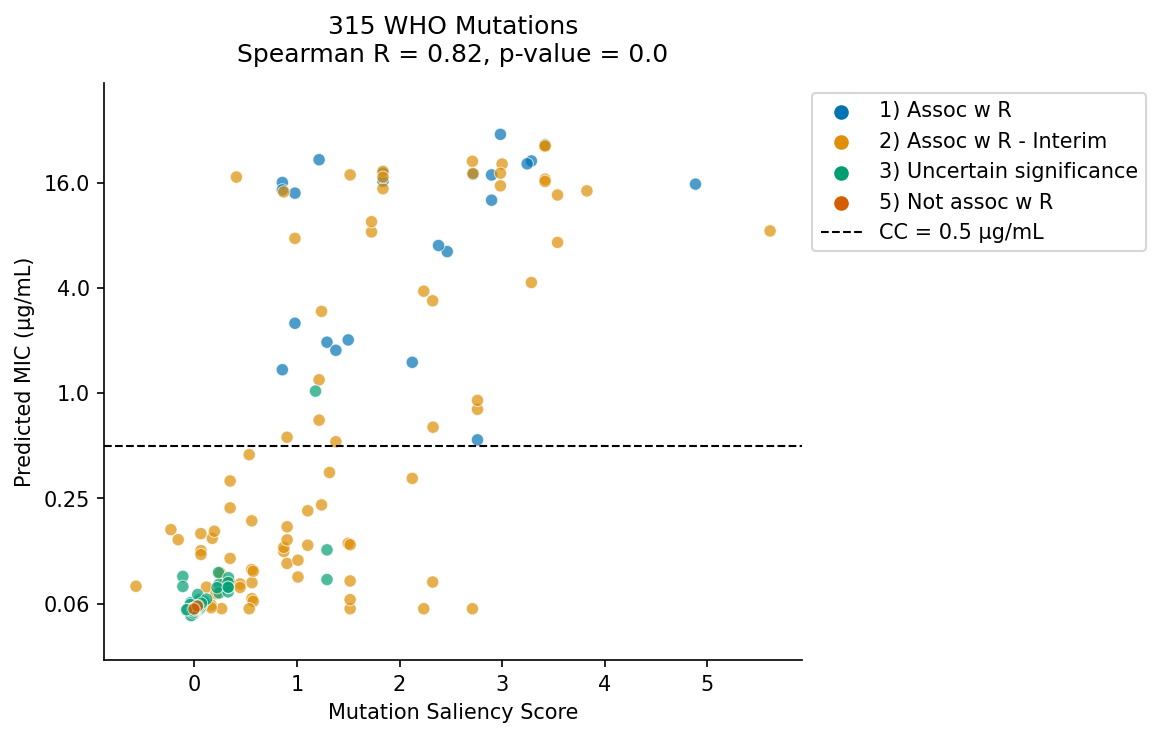

In [171]:
# only plot sites with at least one significant saliency score because the others are not reliable
saliency_scatter_plot(df_RIF_saliency_plot.query("Max_Sig == 1 | Min_Sig == 1"), 
                      corr_type="Spearman", 
                      #saveName="Rifampicin/insilico_mutagenesis/MIC_saliency_scatter.png"
                     )

In [ ]:
# R-associated mutations predicted susceptible
df_rif_saliency_plot.query("confidence=='1) Assoc w R' & log_MIC < -1")

,log_MIC,mutation,confidence,genome_index,MIC,gene,POS,REF,ALT,Gene,Pos,Max,Min,Max_Sig,Min_Sig,WHO,Coll_2014,Freschi_2020,saliency_score
5,-1.675691,rpoB_p.His445Asn,1) Assoc w R,761139,0.313016,rpoB,761139,C,A,rpoBC,761139.0,5.481325,-2.495282,1.0,1.0,1,0,0,5.481325


In [124]:
# uncertain mutation that predicts resistance
thresh = np.log(0.5)
df_rif_saliency_plot.query("log_MIC > @thresh and confidence.str.contains('3')")

,log_MIC,mutation,confidence,genome_index,gene,POS,REF,ALT,Gene,Pos,Max,Min,Max_Sig,Min_Sig,WHO,Coll_2014,Freschi_2020,saliency_score
699,0.039532,rpoB_p.Ile491Tyr,3) Uncertain significance,"761277,761278",rpoB,761277,A,T,rpoBC,761277.0,2.801617,-0.215066,1.0,1.0,1,0,0,1.181174


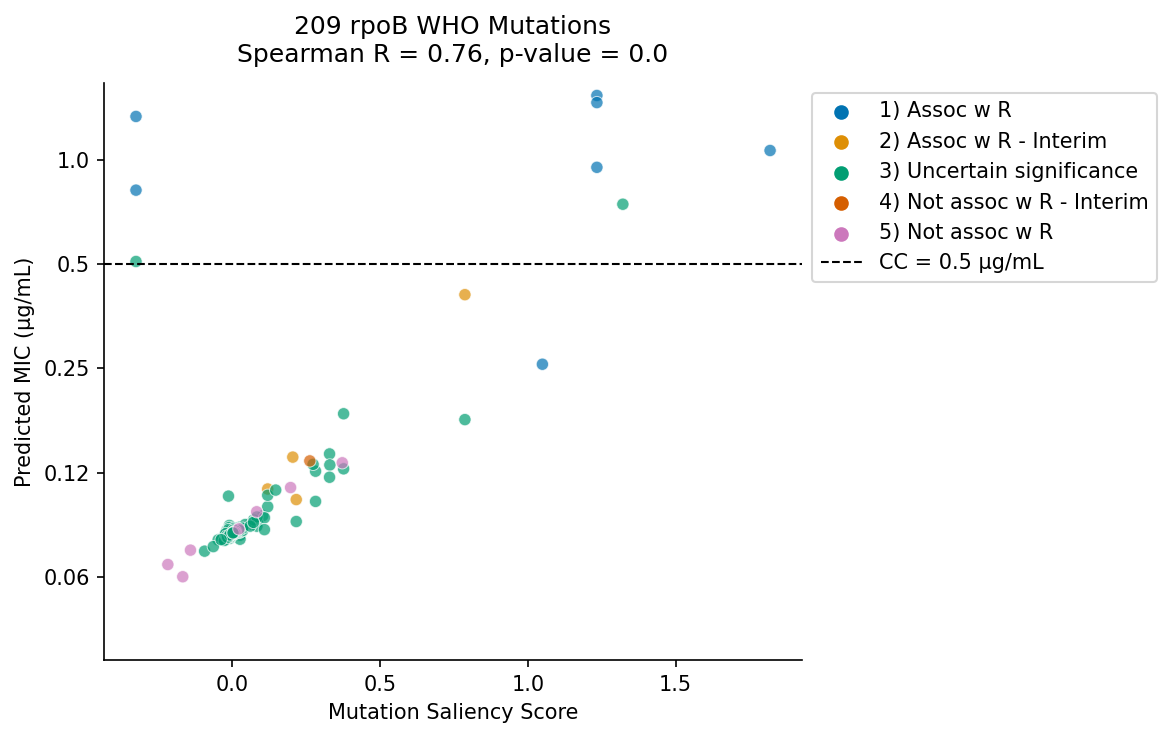

In [120]:
# only plot sites with at least one significant saliency score because the others are not reliable
saliency_scatter_plot(df_MXF_saliency_plot.query("Max_Sig == 1 | Min_Sig == 1"), 
                      corr_type="Spearman", 
                      #saveName="Rifampicin/insilico_mutagenesis/MIC_saliency_scatter.png"
                     )

In [125]:
df_MXF_saliency_plot.query("saliency_score < 0 & log_MIC > @thresh")

,log_MIC,mutation,confidence,genome_index,gene,POS,REF,ALT,Gene,Pos,Max,Min,Max_Sig,Min_Sig,WHO,Coll_2014,Freschi_2020,saliency_score
1,0.417849,gyrA_p.Asp94Gly,1) Assoc w R,7582,gyrA,7582,A,G,gyrBA,7582.0,1.247441,-0.325217,0.0,1.0,1,0,0,-0.325217
3,-0.289461,gyrA_p.Asp94Ala,1) Assoc w R,7582,gyrA,7582,A,C,gyrBA,7582.0,1.247441,-0.325217,0.0,1.0,1,0,0,-0.325217


# Further Investigation of the Group 2 Mutations with Low Saliency Scores or Low Predicted MICs

### Hypothesis: Low saliency = not in the training dataset.
### Low predicted MIC: IDK!


761134 is the only (1/11) category 1 site without a significant positive saliency score in the RIF CNN

In [231]:
plot_df.query("dataset==1 & MIC_pred < @thresh & saliency_score > 2 & confidence.str.contains('|'.join(['1', '2']))")

,mutation,MIC_pred,genome_index,WHO_genome_index,confidence,POS,gene,variant,REF,ALT,Gene,Max,Min,Mean,Max_Sig,Min_Sig,REF_len,ALT_len,saliency_score,dataset
10,rpoB_p.Gln432His,-1.063436,761102,761102,2) Assoc w R - Interim,761102,rpoB,p.Gln432His,A,T,rpoBC,2.071347,0.000000,0.001046,1.0,0.0,1,1,2.071347,1
14,rpoB_p.His445Asn,-1.661120,761139,761139,1) Assoc w R,761139,rpoB,p.His445Asn,C,A,rpoBC,3.437077,0.000000,0.103309,1.0,0.0,1,1,3.437077,1
29,rpoB_p.Asp435Ala,-0.963358,761110,761110,2) Assoc w R - Interim,761110,rpoB,p.Asp435Ala,A,C,rpoBC,4.191139,0.000000,0.223620,1.0,0.0,1,1,4.191139,1
33,rpoB_p.Asp435His,-1.884073,761109,761109,2) Assoc w R - Interim,761109,rpoB,p.Asp435His,G,C,rpoBC,2.973908,-0.722329,0.037628,1.0,1.0,1,1,2.973908,1
47,rpoB_p.Leu430Arg,-1.703787,761095,761095,2) Assoc w R - Interim,761095,rpoB,p.Leu430Arg,T,G,rpoBC,2.659062,0.000000,0.015638,1.0,0.0,1,1,2.659062,1


In [232]:
search_df = plot_df.query("MIC_pred < @thresh & saliency_score > 2 & confidence.str.contains('|'.join(['1', '2']))")
print(search_df.shape)
search_df = search_df[(search_df["REF"].apply(lambda x: len(x) == 1)) & (search_df["ALT"].apply(lambda x: len(x) == 1))]
print(search_df.shape)

(7, 20)
(6, 20)


In [233]:
scores = sparse.load_npz("/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/RIF_rpoBC/saliency/quant/genetic_scores_unpooled_nuc.npy.npz").todense()
# num_samples x 5 nucleotides x longest_locus x num_loci
scores.shape

(7480, 5, 7814, 1)

In [234]:
rif_rpoBC_df = rif_rpoBC_df.reset_index(drop=True)
BASE_TO_COLUMN = {'A': 0, 'C': 1, 'T': 2, 'G': 3, '-': 4}

def plot_nuc_scores_single_pos(pos):
    
    search_idx = rif_rpoBC_df.query("Pos==@pos").index.values[0]
    ref = plot_df.query("POS==@pos")["REF"].unique()[0]

    if rif_rpoBC_df.query("Pos==@pos")["Max_Sig"].values[0] == 1:
        scores_by_nuc = dict(zip(BASE_TO_COLUMN.keys(), np.max(scores[:, :, search_idx, :], axis=0).flatten()))

    elif rif_rpoBC_df.query("Pos==@pos")["Min_Sig"].values[0] == 1:
        scores_by_nuc = dict(zip(BASE_TO_COLUMN.keys(), np.min(scores[:, :, search_idx, :], axis=0).flatten()))

    else:
        raise ValueError(f"{pos} does not have a significant score!")

    plot_df_single_site = plot_df.query("POS==@pos")[["mutation", "MIC_pred", "ALT"]]
    y_col = "MIC_pred"
    
#     plot_df_single_site = rpoBC_seqDF[["Isolate", pos]]
#     plot_df_single_site = plot_df_single_site.merge(df_rif[["ROLLINGDB_ID", "RIF_midpoint"]], left_on="Isolate", right_on="ROLLINGDB_ID", how="inner")

#     plot_df_single_site = pd.DataFrame(plot_df_single_site.groupby(pos)["RIF_midpoint"].mean()).reset_index().rename(columns={pos:"ALT"})
    # y_col = "RIF_midpoint"

    plot_df_single_site["saliency"] = plot_df_single_site["ALT"].map(scores_by_nuc)
    print(plot_df_single_site.sort_values("MIC_pred"))

    fig, ax = plt.subplots(figsize=(3, 2))
    sns.scatterplot(data=plot_df_single_site, x="saliency", y=y_col, ax=ax)
    plt.title(f"POS: {pos}, REF nucleotide: {ref}")

    for _, row in plot_df_single_site.iterrows():
        if row["ALT"] != ref:
            plt.text(row["saliency"]+0.05, row[y_col], row["ALT"])

    sns.despine()
    plt.show()